# Notebook 01: Data Understanding
## Credit Risk & Loan Decision Intelligence Platform
### Phase 1 â€” Step 1: Dataset Familiarization

---

> **Important Notice â€” Synthetic Data**
>
> The dataset used in this notebook (`credit_risk_50.csv`) contains **50 synthetic/demo records**
> created specifically for **learning and development purposes**.
>
> **These are NOT real customer records. These are NOT real banking records.**
> The data was artificially generated to simulate the structure of a credit-risk dataset
> for the purpose of learning the Data Science workflow.

---

### What is this notebook for?

Before we build any model, we need to deeply understand our data.
**A model is only as good as the data that goes into it.**

In this notebook (Step 1), we will answer only these questions:

1. What does this dataset represent?
2. How many rows and columns do we have?
3. What does each column mean?
4. What type of data is in each column?
5. What is our target variable (what are we eventually predicting)?
6. What initial observations can we make?

---

### What we are NOT doing in this step:

- Plotting distributions (that is Step 2 â€” EDA)
- Checking for missing values in detail (that is Step 2)
- Analyzing correlations (that is Step 2)
- Cleaning the data (that is Phase 2)
- Training any model (that is Phase 3)

**Our only job here is: understand the structure and meaning of the data.**

---

## 1. Project Objective

### What are we building?

We are building an **India-focused Credit Risk and Digital Lending Intelligence Platform**.

This is a full-stack Data Science project. The Data Science component will eventually:

- Take information about a loan applicant as input
- **Estimate the probability that the applicant may default** on their loan repayment
- Help a lending system make a smarter, data-driven decision

### Why credit risk?

When a bank or NBFC (Non-Banking Financial Company) gives a loan, there is always a risk:

> *What if the borrower does not repay?*

This is called **credit risk** â€” the risk that a borrower will default (fail to repay).
Lenders need to estimate this risk before approving a loan. Getting it wrong is very expensive:

- **Too strict** means good borrowers are rejected and the lender loses business
- **Too lenient** means bad borrowers are approved and the lender loses money

A machine learning model trained on historical applicant data can help estimate this risk
more consistently and accurately than manual review alone.

### Why India-focused?

India has a large population of **new-to-credit** borrowers â€” people who are applying for
their first loan and have no credit history. Traditional credit scoring (like CIBIL scores)
works poorly for them. This makes ML-based credit risk modeling especially valuable
in the Indian lending market.

### Where are we right now?

We are at the very beginning â€” **Phase 1, Step 1: Dataset Familiarization**.

We are using a **small synthetic dataset** (50 records) to learn and practice the
Data Science workflow before working with larger, more complex real-world data.

> **These 50 records are synthetic/demo records created for learning and development.**
> **They are not real customer or banking records.**

The goal of this phase is not to build a production model â€” it is to **understand the workflow**
so we can apply it correctly when we scale up.

---

## 2. Dataset Overview

Before writing a single line of code, let us understand what we expect to find in this dataset.

| Property | Details |
|---|---|
| **File name** | `credit_risk_50.csv` |
| **Location** | `data/raw/credit_risk_50.csv` |
| **Format** | CSV (Comma-Separated Values) |
| **Records** | 50 synthetic loan applicant records |
| **Origin** | Synthetically generated for learning purposes |
| **Domain** | India-style credit risk and digital lending |
| **Purpose** | Phase 1 EDA and workflow learning only |

### What is a CSV file?

A **CSV (Comma-Separated Values)** file is a plain text file where:
- Each **row** represents one record (in our case, one loan applicant)
- Each **column** represents one attribute about that record (e.g., income, credit score)
- Values in the same row are separated by commas
- The first row contains **column headers** (names)

CSV is the most common format for tabular data in Data Science.
We use **pandas** to load and work with CSV files as DataFrames.

### Why store data in `data/raw/`?

We store the dataset in `data/raw/` following a standard Data Science project convention:

- `data/raw/` holds original, untouched files â€” we never modify these
- `data/processed/` will hold cleaned or transformed data created by our Python code

This separation ensures **reproducibility** â€” we can always trace our work
from the raw input to the final output. If we modified the raw file by hand,
we could never prove exactly what transformations were applied.

---

## 3. Load Dataset

### Why this step?

Before we can analyze anything, we must load the data into Python memory.
We use **pandas** because it is the standard library for working
with tabular data in Python.

### Important: Relative vs. Absolute paths

When loading files in a notebook, we can use two types of paths:

- **Absolute path** is the full path from your computer root, e.g. `C:/Users/yourname/Downloads/...`
  - Problem: This breaks when you open the project on a different computer

- **Relative path** is the path relative to where the notebook is running, e.g. `../data/raw/...`
  - Correct approach: Works for anyone who clones the repository

Since our notebook lives in `notebooks/` and the data is in `data/raw/`,
the relative path goes **one folder up** (`..`) and then into `data/raw/`.

```
project_root/
    data/
        raw/
            credit_risk_50.csv   <- we want this file
    notebooks/
        01_data_understanding.ipynb   <- we are running from here
```

So the relative path is: `'../data/raw/credit_risk_50.csv'`

In [44]:
# IMPORTS
# pandas is the core library for working with tabular (row/column) data.
# It provides the DataFrame object, which is how we represent our dataset in memory.
import pandas as pd

# numpy is a numerical computing library.
# We import it as a standard companion to pandas.
# In Step 1 we will not use it heavily, but it is needed in later steps.
import numpy as np

print('Libraries loaded successfully.')
print(f'pandas version : {pd.__version__}')
print(f'numpy version  : {np.__version__}')

Libraries loaded successfully.
pandas version : 3.0.3
numpy version  : 2.4.6


In [45]:
# DATASET PATH
# We define the path as a named constant variable at the top.
# Good practice: if the file location ever changes, we only update it here
# rather than hunting through the whole notebook.
#
# '../' means: go up one directory level (from notebooks/ to the project root)
# Then navigate into data/raw/ to find our CSV file.
RAW_DATA_PATH = '../data/raw/credit_risk_50.csv'

# LOAD THE CSV
# pd.read_csv() reads the CSV file and returns a pandas DataFrame.
# A DataFrame is like a spreadsheet table: rows and columns with labels.
#
# We do NOT pass index_col here because our dataset already has an
# 'applicant_id' column that we want to keep visible as a regular column.
df = pd.read_csv(RAW_DATA_PATH)

print('Dataset loaded successfully!')
print(f'   File  : {RAW_DATA_PATH}')
print(f'   Rows  : {df.shape[0]}')
print(f'   Cols  : {df.shape[1]}')

Dataset loaded successfully!
   File  : ../data/raw/credit_risk_50.csv
   Rows  : 50
   Cols  : 16


---

## 4. Basic Dataset Inspection

Now that the data is loaded into memory as a DataFrame (`df`), we inspect it
systematically using standard pandas functions.

Each inspection step has a **specific purpose** â€” we do not run them blindly.

| Pandas Function | What it tells us |
|---|---|
| `df.shape` | How many rows and columns the dataset has |
| `df.head()` | First few rows â€” shows structure and sample values |
| `df.tail()` | Last few rows â€” confirms the data was fully loaded |
| `df.columns` | List of all column names |
| `df.info()` | Column names, data types, and non-null counts |
| `df.describe()` | Summary statistics for numerical columns |

In [46]:
# df.shape
# shape is a property (not a function), so we do not use ().
# It returns a tuple: (number_of_rows, number_of_columns).
#
# WHY we check this:
# This is always the very first check. We want to know how big our dataset is.
# How many observations (rows) and how many variables (columns) do we have?
# This sets our expectations for everything that follows.

print('df.shape:', df.shape)
print()
print(f'Our dataset has {df.shape[0]} rows (observations) and {df.shape[1]} columns (variables).')

df.shape: (50, 16)

Our dataset has 50 rows (observations) and 16 columns (variables).


In [47]:
# df.head()
# head() returns the first N rows. The default is N=5.
#
# WHY we check this:
# We look at the first few rows to get a concrete feel for what one record
# looks like â€” what values actually appear in each column.
# This is the fastest way to get oriented with a new dataset.
# Looking at real values helps us verify the data dictionary.

print('First 5 rows of the dataset:')
print('Each row = one synthetic loan applicant record')
print()
df.head()

First 5 rows of the dataset:
Each row = one synthetic loan applicant record



,applicant_id,age,employment_type,monthly_income,loan_amount,loan_term_months,existing_emi,credit_score,credit_utilization_pct,late_payment_count,previous_defaults,employment_years,average_bank_balance,monthly_expenses,debt_to_income_ratio,default
0,1,24,Salaried,35000,150000,24,12000,610,72,3,1,2,18000,22000,0.34,1
1,2,31,Salaried,70000,300000,36,15000,745,31,0,0,7,52000,36000,0.21,0
2,3,45,Salaried,95000,500000,48,20000,780,24,0,0,15,95000,47000,0.21,0
3,4,28,Self-employed,42000,250000,36,22000,625,81,4,1,3,15000,30000,0.52,1
4,5,36,Salaried,62000,280000,36,14000,705,42,1,0,9,44000,35000,0.23,0


In [48]:
# df.tail()
# tail() returns the last N rows. The default is N=5.
#
# WHY we check this:
# We check the last rows to confirm the file was fully loaded into memory.
# Sometimes CSV files get cut off during download or transfer.
# If head() and tail() both show valid rows, the file loaded completely.

print('Last 5 rows of the dataset:')
print('Confirms the file was fully loaded, not truncated mid-way')
print()
df.tail()

Last 5 rows of the dataset:
Confirms the file was fully loaded, not truncated mid-way



,applicant_id,age,employment_type,monthly_income,loan_amount,loan_term_months,existing_emi,credit_score,credit_utilization_pct,late_payment_count,previous_defaults,employment_years,average_bank_balance,monthly_expenses,debt_to_income_ratio,default
45,46,33,Salaried,58000,250000,36,14000,695,52,1,0,7,37000,33000,0.24,0
46,47,40,Self-employed,69000,300000,36,22000,675,67,2,1,9,31000,38000,0.32,1
47,48,56,Salaried,132000,750000,60,32000,805,16,0,0,24,165000,68000,0.24,0
48,49,27,Salaried,39000,170000,24,14000,635,80,4,1,2,12000,26000,0.36,1
49,50,45,Salaried,91000,410000,48,20000,750,30,0,0,16,88000,45000,0.22,0


In [49]:
# df.columns
# columns is a property that returns an Index object with all column names.
# We convert it to a Python list and print them one by one for clarity.
#
# WHY we check this:
# We want to see all column names clearly in one place.
# This helps us understand what variables are available,
# and lets us spot typos, unexpected names, or missing columns.

print('All column names in the dataset:')
print()
all_columns = df.columns.tolist()
for i, col in enumerate(all_columns, start=1):
    print(f'  {i:>2}. {col}')
print()
print(f'Total: {len(all_columns)} columns')

All column names in the dataset:

   1. applicant_id
   2. age
   3. employment_type
   4. monthly_income
   5. loan_amount
   6. loan_term_months
   7. existing_emi
   8. credit_score
   9. credit_utilization_pct
  10. late_payment_count
  11. previous_defaults
  12. employment_years
  13. average_bank_balance
  14. monthly_expenses
  15. debt_to_income_ratio
  16. default

Total: 16 columns


In [50]:
# df.info()
# info() prints a concise summary of the DataFrame:
#   - Each column name
#   - Number of non-null (present) values in each column
#   - Data type of each column (int64, float64, object, etc.)
#   - Memory usage
#
# WHY we check this:
# This is one of the most informative single calls in pandas.
# It instantly reveals two critical things:
#   1. Which columns have missing values (non-null count < total rows)
#   2. Whether columns were loaded with the correct data type
#      (e.g., did a numeric column accidentally load as object/text?)
#
# Data type explanations:
#   int64   = whole numbers (integers)
#   float64 = decimal numbers (floating point)
#   object  = text/strings (or mixed types)
#   bool    = True/False values

print('df.info() â€” column names, data types, non-null counts:')
print()
df.info()

df.info() â€” column names, data types, non-null counts:

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   applicant_id            50 non-null     int64  
 1   age                     50 non-null     int64  
 2   employment_type         50 non-null     str    
 3   monthly_income          50 non-null     int64  
 4   loan_amount             50 non-null     int64  
 5   loan_term_months        50 non-null     int64  
 6   existing_emi            50 non-null     int64  
 7   credit_score            50 non-null     int64  
 8   credit_utilization_pct  50 non-null     int64  
 9   late_payment_count      50 non-null     int64  
 10  previous_defaults       50 non-null     int64  
 11  employment_years        50 non-null     int64  
 12  average_bank_balance    50 non-null     int64  
 13  monthly_expenses        50 non-null     int64  
 1

In [51]:
# df.describe()
# describe() generates summary statistics for all numerical columns:
#   count  = number of non-null values (useful for spotting missing data)
#   mean   = average value
#   std    = standard deviation (how spread out values are around the mean)
#   min    = smallest value in the column
#   25%    = 25th percentile (lower quartile â€” 25% of values are below this)
#   50%    = 50th percentile (median â€” the middle value)
#   75%    = 75th percentile (upper quartile â€” 75% of values are below this)
#   max    = largest value in the column
#
# WHY we check this:
# This gives us a statistical fingerprint of the dataset. We can spot:
#   - Suspicious min/max values (e.g., negative income? age = 0?)
#   - Very large std relative to mean (may indicate outliers)
#   - Difference between mean and median (when they are far apart, the data is skewed)
#
# Important: We do NOT make conclusions here. We just observe.
# Detailed analysis happens in Step 2 (EDA).
#
# .T transposes the result (swaps rows and columns) for easier reading
# when there are many columns.

print('df.describe() â€” summary statistics for numerical columns:')
print('(Transposed using .T so each row is a column from the dataset)')
print()
df.describe().T

df.describe() â€” summary statistics for numerical columns:
(Transposed using .T so each row is a column from the dataset)



,count,mean,std,min,25%,50%,75%,max
applicant_id,50.0,25.5000,14.577380,1.0,13.25,25.50,37.75,50.00
age,50.0,37.0400,9.395961,23.0,29.00,35.50,43.75,57.00
monthly_income,50.0,71160.0000,28131.876030,30000.0,47250.00,68500.00,90750.00,140000.00
loan_amount,50.0,350500.0000,163751.460501,120000.0,232500.00,320000.00,445000.00,800000.00
loan_term_months,50.0,42.9600,12.849140,24.0,36.00,48.00,48.00,60.00
existing_emi,50.0,19820.0000,6080.044307,9000.0,15000.00,19000.00,24000.00,35000.00
credit_score,50.0,697.5000,61.728917,600.0,640.00,697.50,748.75,810.00
credit_utilization_pct,50.0,52.4200,24.000077,15.0,31.50,49.50,75.50,91.00
late_payment_count,50.0,1.6600,1.697657,0.0,0.00,1.00,3.00,6.00
previous_defaults,50.0,0.4000,0.606092,0.0,0.00,0.00,1.00,2.00


---

## 5. What Does One Row Represent?

This is a simple but important concept to establish clearly before going further.

### The fundamental structure of tabular data:

| Concept | Meaning | In our dataset |
|---|---|---|
| **Row** | One observation or one record | One synthetic loan applicant |
| **Column** | One attribute, variable, or feature | A property of that applicant |
| **Cell** | The value at a specific row and column | For example: applicant 3's credit score |

### In our dataset:

**One row represents one synthetic loan application record.**

It captures information about **one applicant** at the time they applied for a loan:
- Their personal profile (age, employment type)
- Their financial situation (income, expenses, existing EMI)
- Their credit history (credit score, previous defaults, late payments)
- The loan they are applying for (loan amount, loan term)
- The **observed outcome** in this synthetic dataset (did they default or not?)

### Important clarification:

> **We are not claiming these are real bank customers.**
>
> These 50 records are **synthetically generated** to simulate the kind of data
> a real credit-risk dataset might contain. The structure is realistic,
> but the individuals are **not real people**.

### Why does this matter?

Understanding what a row represents tells us:
- What unit of analysis we are working with (per applicant, not per bank branch)
- What predictions will be made (one prediction per applicant)
- What the columns should logically contain
- Whether the data is at the right level of granularity for our task

---

## 6. Column-by-Column Understanding

Before analyzing anything statistically, we must understand what each column **means**.

This is called a **Data Dictionary** â€” a mandatory document in any real Data Science project.
Without it, numbers are meaningless. Knowing that `credit_score = 750` is only useful if
we know what a credit score represents and what range is considered good or bad.

| # | Column Name | Meaning | Data Type | Role |
|---|---|---|---|---|
| 1 | `applicant_id` | Unique identifier for each applicant record | Integer | Identifier |
| 2 | `age` | Age of the applicant in years | Integer | Numerical Feature |
| 3 | `employment_type` | Type of employment: Salaried, Self-employed, or Business | Text (String) | Categorical Feature |
| 4 | `monthly_income` | Applicant monthly income in rupees in the synthetic dataset | Integer | Numerical Feature |
| 5 | `loan_amount` | Amount of loan requested in rupees | Integer | Numerical Feature |
| 6 | `loan_term_months` | Duration of the loan repayment period in months | Integer | Numerical Feature |
| 7 | `existing_emi` | Existing monthly EMI debt payments the applicant already has in rupees | Integer | Numerical Feature |
| 8 | `credit_score` | Creditworthiness indicator where higher values indicate better credit history | Integer | Numerical Feature |
| 9 | `credit_utilization_pct` | Percentage of available credit limit currently being used | Float | Numerical Feature |
| 10 | `late_payment_count` | Number of late payment incidents recorded | Integer | Numerical Feature |
| 11 | `previous_defaults` | Number of previous loan defaults recorded in this synthetic dataset | Integer | Numerical Feature |
| 12 | `employment_years` | Number of years the applicant has been employed | Integer | Numerical Feature |
| 13 | `average_bank_balance` | Average bank balance maintained in rupees | Integer | Numerical Feature |
| 14 | `monthly_expenses` | Monthly expenditure of the applicant in rupees | Integer | Numerical Feature |
| 15 | `debt_to_income_ratio` | Ratio of total monthly debt obligations to monthly income | Float | Numerical Feature |
| 16 | `default` | Observed outcome in this synthetic dataset: 0 = no default, 1 = default | Integer (0 or 1) | Target Variable |

---

### Notes on specific columns:

**`applicant_id`** is just an identifier. It has no predictive value.
The number assigned to an applicant tells us nothing about whether they will default.
We will exclude it from model training.

**`employment_type`** is a text/categorical column. It cannot be fed directly into
most ML models as-is. In Phase 2, we will convert it to numbers using a technique
called one-hot encoding.

**`debt_to_income_ratio`** is a derived column â€” it was likely calculated from
other columns (monthly debt divided by monthly income). In real datasets, we would verify this.
We will flag it during feature analysis in Step 2 to watch for potential redundancy.

**`credit_utilization_pct`** represents how much of the available credit limit the
applicant is currently using. High utilization often indicates financial stress in real datasets,
but we will analyze this relationship in Step 2, not here.

**`default`** is our target variable and is discussed in detail in Section 7.

In [52]:
# Verify data dictionary against actual dataset
# This checks that all expected columns exist and confirms their actual data types.
# Always good to cross-check what we documented with what pandas actually loaded.

print('Data dictionary verification:')
print('Checking column names and data types as loaded by pandas')
print()

dtype_summary = pd.DataFrame({
    'Column': df.columns,
    'Pandas dtype': df.dtypes.values,
    'Sample value (row 0)': [df[col].iloc[0] for col in df.columns]
})

print(dtype_summary.to_string(index=False))

Data dictionary verification:
Checking column names and data types as loaded by pandas

                Column Pandas dtype Sample value (row 0)
          applicant_id        int64                    1
                   age        int64                   24
       employment_type          str             Salaried
        monthly_income        int64                35000
           loan_amount        int64               150000
      loan_term_months        int64                   24
          existing_emi        int64                12000
          credit_score        int64                  610
credit_utilization_pct        int64                   72
    late_payment_count        int64                    3
     previous_defaults        int64                    1
      employment_years        int64                    2
  average_bank_balance        int64                18000
      monthly_expenses        int64                22000
  debt_to_income_ratio      float64                 0.34


---

## 7. Target Variable

### What is a target variable?

In **supervised machine learning**, we train a model to predict something.
That something is called the **target variable** (also called label, output variable,
dependent variable, or simply `y`).

The other columns â€” the ones the model uses to make its prediction â€” are called **features**
(also called input variables, predictors, independent variables, or simply `X`).

In our dataset:

- **Target variable** is `default`
- **Features** are all other columns except the identifier `applicant_id`

### What does `default` mean in this synthetic dataset?

| Value | Meaning in this synthetic dataset |
|---|---|
| `0` | The applicant did not default â€” loan was repaid as agreed |
| `1` | The applicant defaulted â€” loan was not repaid as agreed |

> **Important:** We are describing what these values represent within **this synthetic dataset only**.
> In a real banking context, the exact definition of default (for example, 90+ days past due)
> would be specified in the dataset documentation. We do not make that claim here
> because this is synthetic data without that documentation.

### Why is the target variable important?

The target variable is the foundation of the entire project:
- The model's entire job is to predict it
- Its distribution (how many 0s vs 1s) affects which evaluation metrics we use
- Its definition must be completely clear before any modeling begins

If we misunderstand the target variable, everything built on top of it will be wrong.

> **We are NOT training a model here. We are only understanding what we will eventually predict.**

In [53]:
# TARGET VARIABLE â€” UNIQUE VALUES
# We first check what unique values appear in the target column.
# For a binary classification problem, we expect only 0 and 1.
# If unexpected values appear (such as -1, 2, or NaN), we need to investigate.

TARGET_COLUMN = 'default'

print(f"Target variable: '{TARGET_COLUMN}'")
print()

unique_vals = sorted(df[TARGET_COLUMN].unique())
print(f'Unique values found: {unique_vals}')
print('Confirmed: binary target (0 = no default, 1 = default)')

Target variable: 'default'

Unique values found: [np.int64(0), np.int64(1)]
Confirmed: binary target (0 = no default, 1 = default)


In [54]:
# TARGET VARIABLE â€” VALUE COUNTS
# value_counts() counts how many times each unique value appears.
# This tells us how many applicants defaulted vs. did not default.

count_values = df[TARGET_COLUMN].value_counts().sort_index()

print(f"Value counts for '{TARGET_COLUMN}':")
print()
print(f'  default = 0 (did not default) : {count_values[0]} applicants')
print(f'  default = 1 (defaulted)       : {count_values[1]} applicants')
print()
print(f'  Total                         : {count_values.sum()} applicants')

Value counts for 'default':

  default = 0 (did not default) : 31 applicants
  default = 1 (defaulted)       : 19 applicants

  Total                         : 50 applicants


In [55]:
# TARGET VARIABLE â€” PERCENTAGE DISTRIBUTION
# normalize=True converts counts to proportions (0.0 to 1.0).
# We multiply by 100 to express them as percentages.
#
# WHY: We need to understand the PROPORTION of the dataset that defaulted.
# This proportion is called the default rate and it is critical.
# In a later phase, the balance between 0s and 1s will affect which
# evaluation metrics we use when measuring how good our model is.

pct_values = df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100

print(f"Percentage distribution of '{TARGET_COLUMN}':")
print()
print(f'  No default (0) : {pct_values[0]:.1f}%')
print(f'  Default    (1) : {pct_values[1]:.1f}%')
print()
print(f'  Default rate in this synthetic dataset: {pct_values[1]:.1f}%')
print()
print('Note: This distribution is from our 50-record synthetic dataset.')
print('Real-world default rates vary significantly by lender, product, and borrower segment.')
print()
print('Note on class balance: In larger real-world datasets, defaults are often rare')
print('(for example, 5 to 10 percent). This class imbalance matters a lot for model')
print('evaluation. We will revisit this concept in Phase 3.')

Percentage distribution of 'default':

  No default (0) : 62.0%
  Default    (1) : 38.0%

  Default rate in this synthetic dataset: 38.0%

Note: This distribution is from our 50-record synthetic dataset.
Real-world default rates vary significantly by lender, product, and borrower segment.

Note on class balance: In larger real-world datasets, defaults are often rare
(for example, 5 to 10 percent). This class imbalance matters a lot for model
evaluation. We will revisit this concept in Phase 3.


---

## 8. Feature Types

Not all columns are the same. In Data Science, we classify variables by their **type**
because different types require different treatment during analysis and modeling.

---

### Category 1 â€” Identifier

| Column | Why it is an identifier |
|---|---|
| `applicant_id` | Unique ID for each row â€” carries no predictive information |

An identifier is a column that uniquely labels each row. It has no relationship with
whether the applicant will default. We keep it in the DataFrame for reference
but **exclude it from model training**.

---

### Category 2 â€” Categorical Feature

| Column | Possible values | Why it is categorical |
|---|---|---|
| `employment_type` | Salaried, Self-employed, Business | Discrete named groups, not numbers |

A categorical feature contains values that fall into distinct **named groups or categories**.
There is no inherent mathematical order between them (Salaried is not greater than Self-employed).

Most ML models only work with numbers. A text column like `employment_type` must be
**encoded** (converted to numbers) before model training. We will handle this in Phase 2.

---

### Category 3 â€” Numerical Features

| Column | What it measures |
|---|---|
| `age` | Applicant age in years |
| `monthly_income` | Monthly income in rupees |
| `loan_amount` | Loan amount requested in rupees |
| `loan_term_months` | Repayment duration in months |
| `existing_emi` | Existing monthly debt payment in rupees |
| `credit_score` | Creditworthiness indicator |
| `credit_utilization_pct` | Percentage of credit limit used |
| `late_payment_count` | Number of late payment incidents |
| `previous_defaults` | Number of prior defaults |
| `employment_years` | Years of employment |
| `average_bank_balance` | Average bank balance in rupees |
| `monthly_expenses` | Monthly expenditure in rupees |
| `debt_to_income_ratio` | Debt divided by income ratio |

A numerical feature contains measurable quantities on a numeric scale.
These can be integers (whole numbers) or floats (decimal numbers).

> **Important clarification:**
>
> Just because a column is numerical does not automatically make it a model feature.
> We are listing these as **variables available for analysis** right now.
> The final decision on which columns to include in the model will be made in **Phase 2**,
> after data quality checks, leakage analysis, and correlation analysis.

---

### Category 4 â€” Target Variable

| Column | Values | Meaning |
|---|---|---|
| `default` | 0 or 1 | What the model will eventually be trained to predict |

The target variable is fundamentally different from features.
It is what we are trying to **predict**, not what we use to predict.
It must never be used as an input to the model.

In [56]:
# PROGRAMMATIC FEATURE CLASSIFICATION
# We define our classification in Python variables so they can be reused
# in subsequent notebooks without retyping the same column lists.

IDENTIFIER_COL = ['applicant_id']

CATEGORICAL_FEATURES = ['employment_type']

NUMERICAL_FEATURES = [
    'age',
    'monthly_income',
    'loan_amount',
    'loan_term_months',
    'existing_emi',
    'credit_score',
    'credit_utilization_pct',
    'late_payment_count',
    'previous_defaults',
    'employment_years',
    'average_bank_balance',
    'monthly_expenses',
    'debt_to_income_ratio'
]

TARGET_COLUMN = 'default'

# VERIFICATION
# We verify that our classification covers every column exactly once.
# If any column is missing or duplicated, Python will catch it here.
classified = IDENTIFIER_COL + CATEGORICAL_FEATURES + NUMERICAL_FEATURES + [TARGET_COLUMN]
all_cols = df.columns.tolist()

print('Feature classification summary:')
print()
print(f'  Identifier        : {IDENTIFIER_COL}')
print(f'  Categorical       : {CATEGORICAL_FEATURES}')
print(f'  Numerical         : {len(NUMERICAL_FEATURES)} columns')
for col in NUMERICAL_FEATURES:
    print(f'                        {col}')
print(f'  Target variable   : [{repr(TARGET_COLUMN)}]')
print()
print(f'  Total classified  : {len(classified)} columns')
print(f'  Total in dataset  : {len(all_cols)} columns')
print()

if set(classified) == set(all_cols):
    print('All columns are accounted for. Classification is complete.')
else:
    missing_from_classification = set(all_cols) - set(classified)
    extra_in_classification = set(classified) - set(all_cols)
    if missing_from_classification:
        print(f'Columns in dataset but NOT classified: {missing_from_classification}')
    if extra_in_classification:
        print(f'Columns classified but NOT in dataset: {extra_in_classification}')

Feature classification summary:

  Identifier        : ['applicant_id']
  Categorical       : ['employment_type']
  Numerical         : 13 columns
                        age
                        monthly_income
                        loan_amount
                        loan_term_months
                        existing_emi
                        credit_score
                        credit_utilization_pct
                        late_payment_count
                        previous_defaults
                        employment_years
                        average_bank_balance
                        monthly_expenses
                        debt_to_income_ratio
  Target variable   : ['default']

  Total classified  : 16 columns
  Total in dataset  : 16 columns

All columns are accounted for. Classification is complete.


In [57]:
# CATEGORICAL COLUMN â€” CLOSER LOOK
# For categorical features, the first question is: what are the unique categories?
# We need to know how many distinct groups exist and exactly how they are spelled.
# Spelling inconsistencies (e.g., 'salaried' vs 'Salaried') would cause problems in modeling.

print("Categorical column: 'employment_type'")
print()
print('Unique categories found in the dataset:')
emp_counts = df['employment_type'].value_counts()
for category, count in emp_counts.items():
    print(f"  '{category}' : {count} applicants")
print()
print(f'Total unique categories: {df["employment_type"].nunique()}')

Categorical column: 'employment_type'

Unique categories found in the dataset:
  'Salaried' : 33 applicants
  'Self-employed' : 9 applicants
  'Business' : 8 applicants

Total unique categories: 3


---

## 9. Initial Observations

Based on the dataset inspection we just completed, we record our first observations.

**Important rule for this section:**
We only write observations that are **directly supported by the data we have seen**.

We do NOT:
- Make causal claims such as 'X causes default'
- Draw business conclusions yet
- Perform statistical correlation analysis yet

These observations serve as a starting point for Step 2 (Exploratory Data Analysis).

---

### Dataset Size and Structure

- The dataset contains **50 observations** (rows) and **16 columns**
- Each row represents one synthetic loan applicant record
- The dataset is intentionally small â€” appropriate for this learning and workflow stage

### Column Types

- 1 identifier column: `applicant_id` â€” will be excluded from modeling
- 1 categorical column: `employment_type` â€” will require encoding in Phase 2
- 13 numerical columns: various personal and financial attributes
- 1 target column: `default` â€” what we are learning to predict

### Target Variable

- `default` is a binary variable taking only values 0 or 1
- The dataset contains both default and non-default records
- This makes it suitable for a binary classification task
- The exact balance was confirmed in Section 7 above

### Data Types

- All numerical columns were loaded with the correct data types (int64 or float64)
- `employment_type` was correctly loaded as an object (string) type
- No unexpected data type issues were observed at this stage

### Column Content â€” What Information We Have

Columns represent information across several domains:

- **Personal profile**: `age`, `employment_type`, `employment_years`
- **Income and expenses**: `monthly_income`, `monthly_expenses`, `average_bank_balance`
- **Loan details**: `loan_amount`, `loan_term_months`
- **Debt and obligations**: `existing_emi`, `debt_to_income_ratio`
- **Credit history**: `credit_score`, `credit_utilization_pct`, `late_payment_count`, `previous_defaults`

### What to Investigate in Step 2

The following questions will be explored in Step 2 â€” Detailed EDA:

1. Are there any missing values in any column?
2. How are the numerical columns distributed? Skewed or symmetric?
3. Are there any obvious outliers or suspicious values?
4. How do feature values differ between defaulters and non-defaulters?
5. Which features appear most associated with the target variable?
6. Is `debt_to_income_ratio` derived from other columns in the dataset?

---

> **Do NOT proceed to Step 2 without explicit confirmation.**

In [58]:
# STEP 1 COMPLETION SUMMARY
# A final programmatic summary confirming everything is in order.

print('=' * 62)
print('  PHASE 1 - STEP 1: DATASET FAMILIARIZATION')
print('  Completion Summary')
print('=' * 62)
print()
print(f'  Dataset file      : {RAW_DATA_PATH}')
print(f'  Total rows        : {df.shape[0]}')
print(f'  Total columns     : {df.shape[1]}')
print(f'  Identifier cols   : {len(IDENTIFIER_COL)}')
print(f'  Categorical cols  : {len(CATEGORICAL_FEATURES)}')
print(f'  Numerical cols    : {len(NUMERICAL_FEATURES)}')
print(f'  Target column     : {repr(TARGET_COLUMN)}')
print(f'  Target values     : {sorted(df[TARGET_COLUMN].unique())}')
print(f'  Default rate      : {df[TARGET_COLUMN].mean() * 100:.1f}%')
print()
print('  Data type         : SYNTHETIC')
print('  Not real customer or banking data')
print('  Purpose           : Learning and portfolio development only')
print()
print('=' * 62)
print('  Step 1 complete. Awaiting confirmation to proceed to Step 2.')
print('=' * 62)

  PHASE 1 - STEP 1: DATASET FAMILIARIZATION
  Completion Summary

  Dataset file      : ../data/raw/credit_risk_50.csv
  Total rows        : 50
  Total columns     : 16
  Identifier cols   : 1
  Categorical cols  : 1
  Numerical cols    : 13
  Target column     : 'default'
  Target values     : [np.int64(0), np.int64(1)]
  Default rate      : 38.0%

  Data type         : SYNTHETIC
  Not real customer or banking data
  Purpose           : Learning and portfolio development only

  Step 1 complete. Awaiting confirmation to proceed to Step 2.


---

---

# PHASE 1 — STEP 2
# Data Quality + Exploratory Data Analysis

---

**Step 1 (Dataset Familiarization) is complete above.**

In Step 2, we move from *understanding what the data contains* to
*checking whether the data is clean and well-behaved*.

### What we will do in Step 2:

1. Check for **missing values** — are any cells empty?
2. Check for **duplicate records** — are any rows repeated?
3. Verify **data types** — is each column stored correctly?
4. Examine **numerical distributions** — what do the numbers look like?
5. Examine **categorical distributions** — how are categories distributed?
6. Visualize the **target variable** distribution
7. Investigate **potential unusual values** — are there extreme observations?
8. Perform **data validity checks** — do values make logical sense?

### What we will NOT do in Step 2:

- Fix, impute, or remove any data (that is Phase 2: Preprocessing)
- Analyze feature-vs-target relationships (that is Step 3)
- Build correlations or feature importance (that is Step 3)
- Train any model (that is Phase 3)

### Why do we need a separate data quality step?

In real projects, data is messy. Fields are blank, rows are duplicated,
columns have wrong types, and values can be nonsensical. If we build a model
on dirty data, **the model learns from the dirt** — and makes bad predictions.

Data quality checking is like inspecting ingredients before cooking.
You would not put rotten tomatoes in a sauce and hope the dish turns out well.

> **Reminder:** This dataset contains 50 **synthetic** records created for learning.
> It is NOT real customer or banking data.

---

## Step 2 — Additional Imports

In Step 1 we imported only pandas and numpy because we were not creating any plots.
For Step 2, we also need **matplotlib** and **seaborn** for visualizations.

- **matplotlib** is Python's foundational plotting library. We use it to create
  histograms, bar charts, and box plots.
- **seaborn** builds on top of matplotlib and makes statistical plots easier
  to create with better default styling.

In [59]:
# STEP 2 ADDITIONAL IMPORTS
# matplotlib is the base plotting library in Python.
import matplotlib.pyplot as plt

# seaborn makes statistical plots cleaner and easier.
import seaborn as sns

# Tell matplotlib to display plots directly inside the notebook
# instead of opening a separate window.
%matplotlib inline

# Use a clean, modern plot style.
plt.style.use('seaborn-v0_8-whitegrid')

# Make pandas show all columns when printing DataFrames.
pd.set_option('display.max_columns', 20)

print('Step 2 visualization libraries loaded.')
print(f'matplotlib version : {plt.matplotlib.__version__}')
print(f'seaborn version    : {sns.__version__}')

Step 2 visualization libraries loaded.
matplotlib version : 3.11.1
seaborn version    : 0.13.2


---

## S2.1 — Missing Values

### What are missing values?

A missing value means a cell in our dataset has **no data** — it is blank.
In pandas, missing values are represented as `NaN` (Not a Number) or `None`.

### Why do we check for them?

Missing values are one of the most common data quality problems:

- Most ML algorithms **cannot handle missing values** directly.
  If we pass a dataset with NaN values to a model, it will either crash or produce wrong results.
- Missing values may indicate a **data collection problem** — for example, an applicant skipped
  a form field, or a system failed to record a value.
- The **pattern** of missingness can itself be informative. For example, if income is missing
  more often for self-employed applicants, that is a useful observation.

### What we do here:

We **identify and count** missing values. We do **not** fix them yet.
Fixing (imputing) missing values is a preprocessing step that belongs in Phase 2.

In [60]:
# MISSING VALUES CHECK
# isnull() returns True for each cell that is NaN/None.
# .sum() counts the True values per column.
#
# We also calculate the percentage of values missing in each column.
# A column with 2% missing is very different from one with 50% missing.

missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing_count.values,
    'Missing %': missing_pct.values.round(2)
})

print('Missing Values Summary')
print('=' * 50)
print()
print(missing_summary.to_string(index=False))
print()

total_missing = missing_count.sum()
if total_missing == 0:
    print('Result: No missing values were found in any column.')
    print()
    print('This is expected for our 50-row synthetic dataset,')
    print('which was generated without introducing missing values.')
    print('In real-world datasets, missing values are very common.')
else:
    print(f'Result: {total_missing} missing value(s) found.')
    print('These will need to be addressed in Phase 2 (Preprocessing).')

Missing Values Summary

                Column  Missing Count  Missing %
          applicant_id              0        0.0
                   age              0        0.0
       employment_type              0        0.0
        monthly_income              0        0.0
           loan_amount              0        0.0
      loan_term_months              0        0.0
          existing_emi              0        0.0
          credit_score              0        0.0
credit_utilization_pct              0        0.0
    late_payment_count              0        0.0
     previous_defaults              0        0.0
      employment_years              0        0.0
  average_bank_balance              0        0.0
      monthly_expenses              0        0.0
  debt_to_income_ratio              0        0.0
               default              0        0.0

Result: No missing values were found in any column.

This is expected for our 50-row synthetic dataset,
which was generated without introducin

---

## S2.2 — Duplicate Records

### What are duplicates?

There are two types of duplicates we need to check:

1. **Completely duplicated rows** — every single column value is identical across two or more rows.
   This usually means the same record was accidentally entered twice.

2. **Duplicate identifiers** — two rows share the same `applicant_id` but may have different
   values in other columns. This could indicate a data entry error or a legitimate re-application.

### Why do we check?

- Duplicate rows **inflate the dataset** — the model sees the same observation multiple times,
  which can bias it toward that observation's pattern.
- Duplicate IDs with different values create **ambiguity** — which record is correct?

### What we do here:

We **identify** duplicates. We do **not** delete them yet.
Deciding how to handle duplicates is a preprocessing decision for Phase 2.

In [61]:
# CHECK 1: Completely duplicated rows
# duplicated() returns True for each row that is an exact copy of an earlier row.
# By default it keeps the first occurrence and marks subsequent copies as True.

full_duplicates = df.duplicated().sum()

print('Duplicate Rows Check')
print('=' * 50)
print()
print(f'Completely duplicated rows: {full_duplicates}')
print()
if full_duplicates == 0:
    print('Result: No completely duplicated rows found.')
    print('Every row in the dataset is unique.')
else:
    print(f'Result: {full_duplicates} duplicate row(s) found.')
    print('These should be investigated in Phase 2.')

Duplicate Rows Check

Completely duplicated rows: 0

Result: No completely duplicated rows found.
Every row in the dataset is unique.


In [62]:
# CHECK 2: Duplicate applicant_id values
# Each applicant should have a unique ID.
# If two rows share the same applicant_id, something may be wrong.

id_duplicates = df['applicant_id'].duplicated().sum()
total_ids = df['applicant_id'].nunique()

print('Duplicate Applicant ID Check')
print('=' * 50)
print()
print(f'Total rows in dataset     : {len(df)}')
print(f'Unique applicant_id values: {total_ids}')
print(f'Duplicate applicant_ids   : {id_duplicates}')
print()
if id_duplicates == 0:
    print('Result: Every applicant_id is unique.')
    print('Each row represents a distinct applicant record.')
else:
    print(f'Result: {id_duplicates} duplicate applicant_id(s) found.')
    print('These need investigation: same applicant with different data?')

Duplicate Applicant ID Check

Total rows in dataset     : 50
Unique applicant_id values: 50
Duplicate applicant_ids   : 0

Result: Every applicant_id is unique.
Each row represents a distinct applicant record.


---

## S2.3 — Data Types Review

### Why check data types again?

In Step 1, we used `df.info()` to see data types. Here we do a more structured review
by comparing what pandas **actually loaded** against what each column **should logically be**.

Common problems:

- A **numerical column** loaded as `object` (text) — happens when the CSV has commas
  in numbers (e.g., `1,00,000`) or contains a stray text value.
- A **binary column** like `default` loaded as `float64` instead of `int64` — happens
  when there are missing values (pandas converts int to float to accommodate NaN).
- A **categorical column** loaded as `int64` — happens when categories are coded as
  numbers (e.g., 1, 2, 3 instead of Salaried, Self-employed, Business).

Incorrect data types can silently produce wrong results in analysis and modeling.

In [63]:
# DATA TYPE COMPARISON
# We create a table mapping each column to:
#   - Its actual pandas data type (what was loaded)
#   - Its expected logical category (what it should be)

# Define what we expect each column to be
expected_categories = {
    'applicant_id': 'Identifier',
    'age': 'Numerical',
    'employment_type': 'Categorical',
    'monthly_income': 'Numerical',
    'loan_amount': 'Numerical',
    'loan_term_months': 'Numerical',
    'existing_emi': 'Numerical',
    'credit_score': 'Numerical',
    'credit_utilization_pct': 'Numerical',
    'late_payment_count': 'Numerical',
    'previous_defaults': 'Numerical',
    'employment_years': 'Numerical',
    'average_bank_balance': 'Numerical',
    'monthly_expenses': 'Numerical',
    'debt_to_income_ratio': 'Numerical',
    'default': 'Target (Binary)'
}

dtype_review = pd.DataFrame({
    'Column': df.columns,
    'Pandas dtype': df.dtypes.values.astype(str),
    'Expected Category': [expected_categories.get(col, 'Unknown') for col in df.columns]
})

print('Data Type Review')
print('=' * 60)
print()
print(dtype_review.to_string(index=False))
print()

# Flag any potential issues
issues = []
for col in df.columns:
    dtype = str(df[col].dtype)
    expected = expected_categories.get(col, '')
    if expected == 'Numerical' and dtype == 'object':
        issues.append(f"  {col}: loaded as text (object) but expected to be numerical")
    if expected == 'Categorical' and dtype != 'object':
        issues.append(f"  {col}: loaded as {dtype} but expected to be categorical (object)")
    if expected == 'Target (Binary)' and dtype not in ('int64', 'int32'):
        issues.append(f"  {col}: loaded as {dtype} but expected to be integer (binary 0/1)")

if issues:
    print('Potential data type issues:')
    for issue in issues:
        print(issue)
else:
    print('Result: All data types are appropriate.')
    print('Numerical columns are int64 or float64.')
    print('Categorical column (employment_type) is object (text).')
    print('Target column (default) is int64 (binary 0/1).')

Data Type Review

                Column Pandas dtype Expected Category
          applicant_id        int64        Identifier
                   age        int64         Numerical
       employment_type          str       Categorical
        monthly_income        int64         Numerical
           loan_amount        int64         Numerical
      loan_term_months        int64         Numerical
          existing_emi        int64         Numerical
          credit_score        int64         Numerical
credit_utilization_pct        int64         Numerical
    late_payment_count        int64         Numerical
     previous_defaults        int64         Numerical
      employment_years        int64         Numerical
  average_bank_balance        int64         Numerical
      monthly_expenses        int64         Numerical
  debt_to_income_ratio      float64         Numerical
               default        int64   Target (Binary)

Potential data type issues:
  employment_type: loaded as str bu

---

## S2.4 — Numerical Data Overview

### What are we doing?

We use `df.describe()` to get summary statistics for every numerical column.
But unlike Step 1, we will now **interpret** what these numbers tell us.

### Key statistics and what they mean:

| Statistic | What it tells us |
|---|---|
| **count** | Number of non-null values (if less than 50, there are missing values) |
| **mean** | The average value |
| **std** | Standard deviation — how spread out values are around the mean |
| **min** | Smallest value — check if it makes sense (e.g., negative age?) |
| **25%** | Lower quartile — 25% of values are below this |
| **50%** | Median — the middle value (robust to outliers, unlike mean) |
| **75%** | Upper quartile — 75% of values are below this |
| **max** | Largest value — check if it makes sense |

### What to look for:

- **Mean vs Median**: If mean and median are far apart, the distribution is **skewed**.
  A mean much higher than the median means a few large values are pulling the average up.
- **Min and Max**: Are these values physically possible and logically sensible?
- **Standard deviation**: A very large std relative to the mean suggests high variability
  or the presence of extreme values.

In [64]:
# NUMERICAL STATISTICS
# We exclude applicant_id (identifier) and default (target) from this analysis
# because they are not features we would analyze statistically.
#
# .T transposes for readability (columns become rows).

numerical_stats = df[NUMERICAL_FEATURES].describe().T

# Add the median explicitly (it is the 50% row, but let us name it clearly)
numerical_stats['median'] = df[NUMERICAL_FEATURES].median()

# Reorder columns for clearer reading
numerical_stats = numerical_stats[['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']]

print('Descriptive Statistics for Numerical Features')
print('=' * 90)
print()
print(numerical_stats.round(2).to_string())
print()
print('Note: count = 50 for all columns means no missing values in numerical features.')

Descriptive Statistics for Numerical Features

                        count       mean     median        std       min        25%        50%        75%        max
age                      50.0      37.04      35.50       9.40      23.0      29.00      35.50      43.75      57.00
monthly_income           50.0   71160.00   68500.00   28131.88   30000.0   47250.00   68500.00   90750.00  140000.00
loan_amount              50.0  350500.00  320000.00  163751.46  120000.0  232500.00  320000.00  445000.00  800000.00
loan_term_months         50.0      42.96      48.00      12.85      24.0      36.00      48.00      48.00      60.00
existing_emi             50.0   19820.00   19000.00    6080.04    9000.0   15000.00   19000.00   24000.00   35000.00
credit_score             50.0     697.50     697.50      61.73     600.0     640.00     697.50     748.75     810.00
credit_utilization_pct   50.0      52.42      49.50      24.00      15.0      31.50      49.50      75.50      91.00
late_payment_coun

### Interpreting the numerical statistics

Here we note what the statistics tell us for key columns.
We are making **observations**, not conclusions.

**Income-related columns** (`monthly_income`, `monthly_expenses`, `average_bank_balance`):
- These columns have wide ranges, which is expected — different applicants have
  very different financial situations.
- If the mean is noticeably higher than the median, a few high-income applicants
  may be pulling the average up. This is common in income data.

**Credit-related columns** (`credit_score`, `credit_utilization_pct`):
- Credit scores have a bounded range in this synthetic dataset.
- Credit utilization percentage should logically be between 0 and 100.

**Count-type columns** (`late_payment_count`, `previous_defaults`):
- These represent counts of events, so their minimum should be 0.
- A median of 0 would mean most applicants have no late payments or defaults.

**Ratio columns** (`debt_to_income_ratio`):
- This is a derived ratio. Its range tells us how leveraged applicants are.
- A value of 0.5 means half of income goes to debt.

We will visualize these distributions next to better understand their shapes.

---

## S2.5 — Numerical Distributions

### What is a distribution?

A **distribution** shows how values in a column are spread out.
It answers the question: *"How many observations fall into each value range?"*

### Why visualize distributions?

Numbers alone (mean, median, std) do not tell the full story.
Two datasets can have the same mean and std but look completely different.
Visualizations let us see:

- **Shape**: Is the data symmetric (bell curve), skewed left/right, or flat?
- **Peaks**: Where do most values concentrate?
- **Spread**: How wide is the range of values?
- **Gaps/clusters**: Are there gaps or unexpected clusters in the data?

### What plots do we use?

- **Histogram**: Shows how many observations fall into each value range (bin).
  Best for seeing the overall shape of the distribution.
- **Box plot**: Shows the median, quartiles, and potential outliers.
  Best for spotting extreme values and comparing spread.

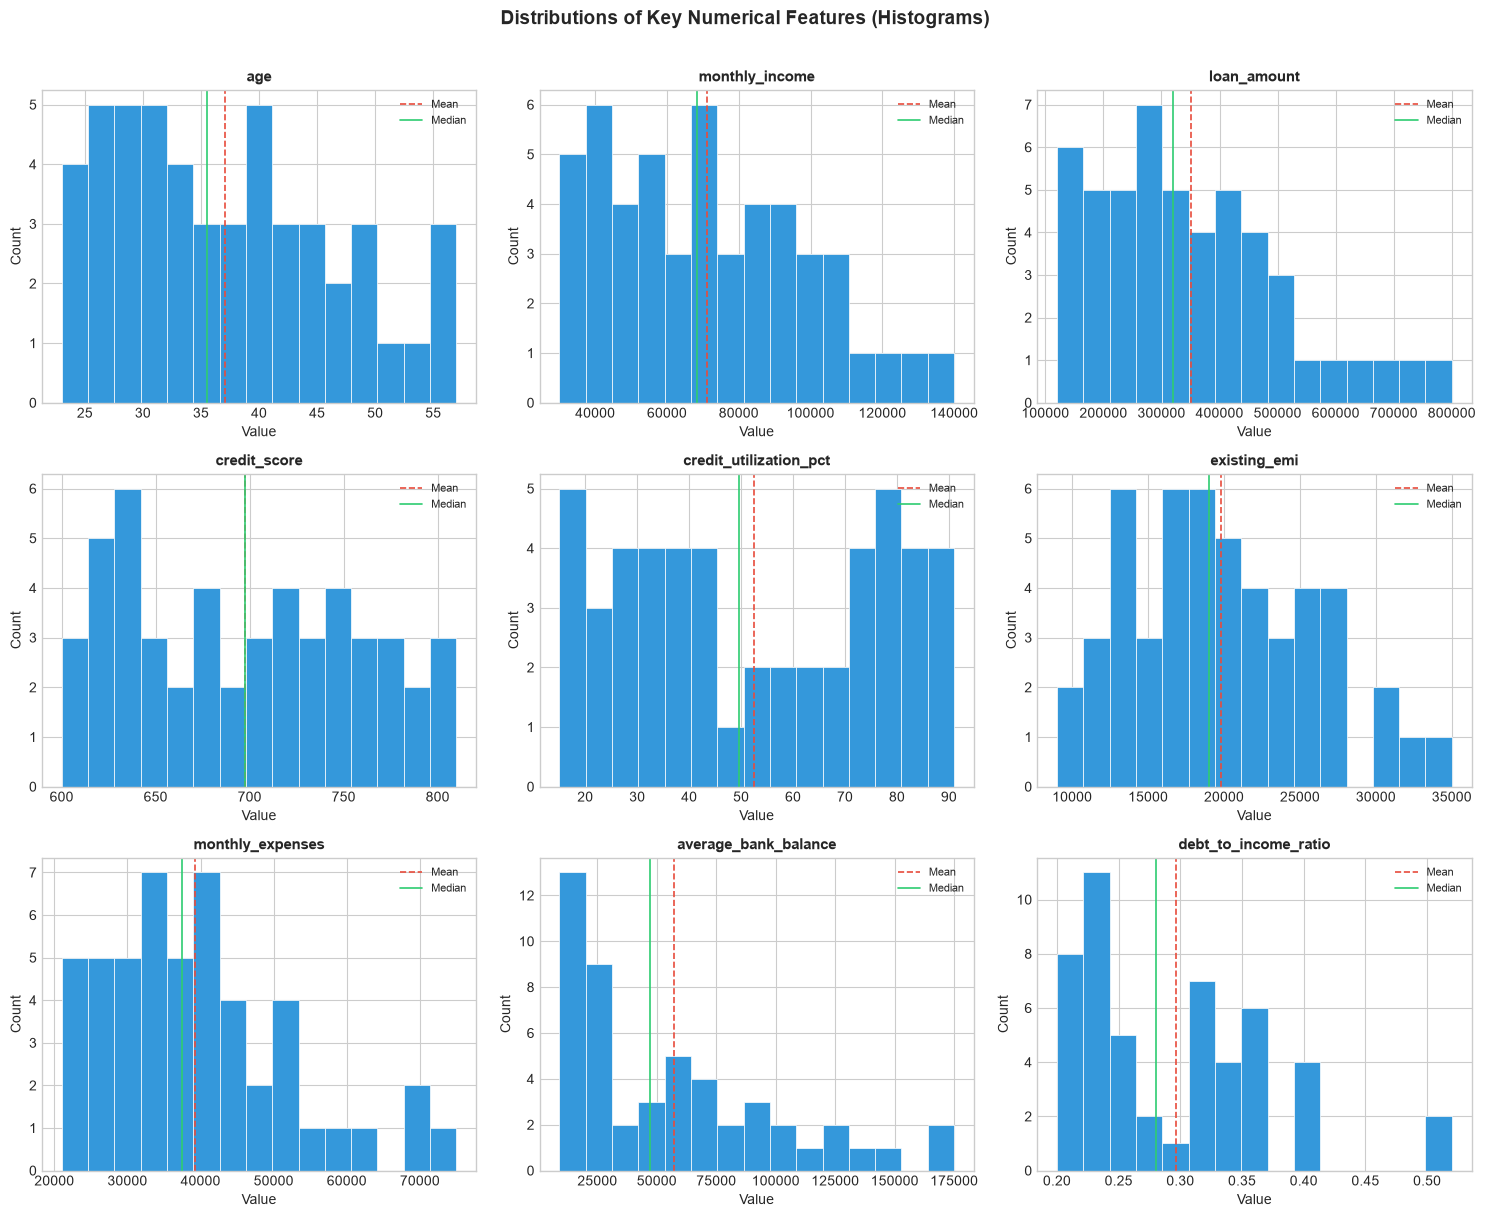


Red dashed line = Mean | Green solid line = Median
When the red line is far from the green line, the distribution is skewed.


In [65]:
# HISTOGRAMS FOR KEY NUMERICAL FEATURES
# We create histograms for the most important numerical columns.
# Each histogram shows how values are spread across different ranges.
#
# bins=15 divides the value range into 15 equal intervals.
# With only 50 data points, too many bins would make the histogram
# look sparse and hard to read.

hist_features = [
    'age', 'monthly_income', 'loan_amount', 'credit_score',
    'credit_utilization_pct', 'existing_emi', 'monthly_expenses',
    'average_bank_balance', 'debt_to_income_ratio'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(hist_features):
    axes[i].hist(df[col], bins=15, color='#3498db', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    # Show mean and median as vertical lines
    axes[i].axvline(df[col].mean(), color='#e74c3c', linestyle='--', linewidth=1.2, label='Mean')
    axes[i].axvline(df[col].median(), color='#2ecc71', linestyle='-', linewidth=1.2, label='Median')
    axes[i].legend(fontsize=8)

plt.suptitle('Distributions of Key Numerical Features (Histograms)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print()
print('Red dashed line = Mean | Green solid line = Median')
print('When the red line is far from the green line, the distribution is skewed.')

### Reading the histograms

For each histogram above, ask yourself:

1. **Is it symmetric or skewed?** If most bars are on the left with a tail stretching right,
   the distribution is *right-skewed* (positively skewed). This is common for income and loan amounts.

2. **Are the mean and median close?** If yes, the distribution is roughly symmetric.
   If the mean is pulled away from the median, a few extreme values are influencing the average.

3. **Are there gaps or clusters?** For example, `loan_term_months` may show only a few
   distinct values (24, 36, 48, 60) because loan terms come in fixed increments.

We do **not** make causal claims here. We are just observing shapes.

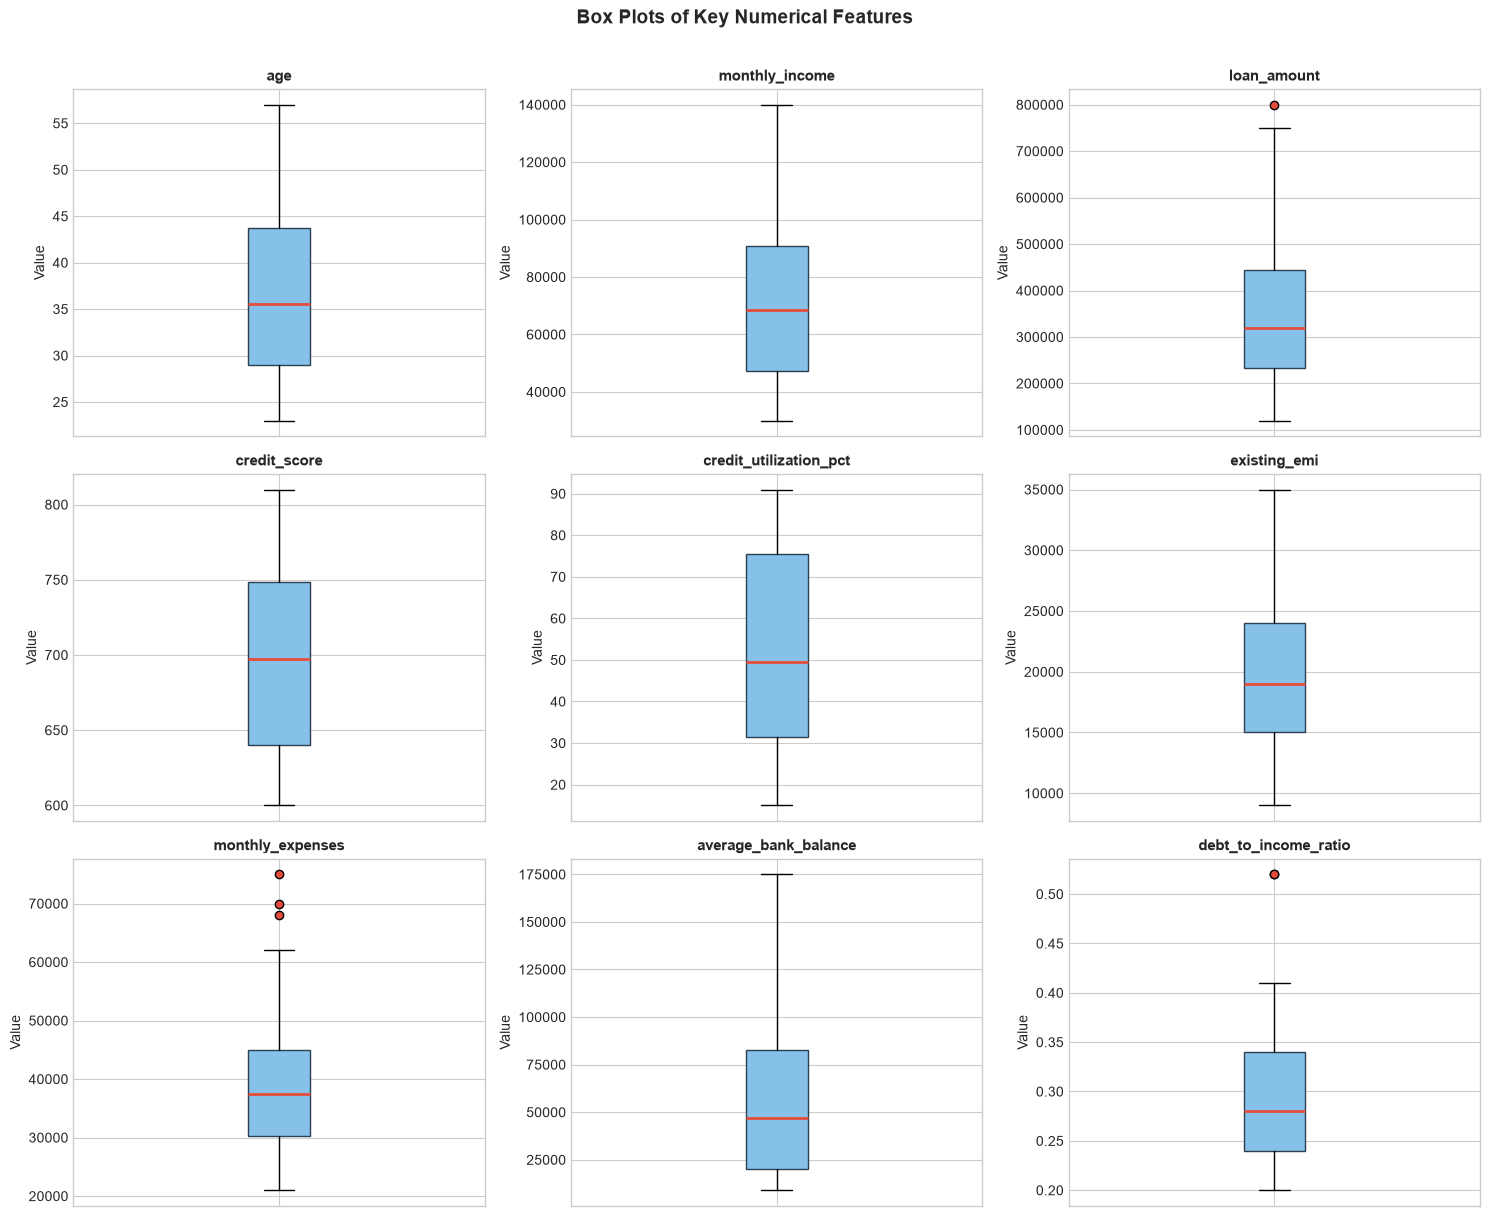


Box = Q1 to Q3 (middle 50% of data)
Line in box = Median
Whiskers = 1.5 x IQR from box edges
Red dots beyond whiskers = potential unusual values


In [66]:
# BOX PLOTS FOR KEY NUMERICAL FEATURES
# A box plot shows:
#   - The box spans from Q1 (25th percentile) to Q3 (75th percentile)
#   - The line inside the box is the median (50th percentile)
#   - The whiskers extend to 1.5 * IQR from the box edges
#   - Points beyond the whiskers are shown as individual dots (potential outliers)
#
# IQR = Interquartile Range = Q3 - Q1
# This is a standard statistical method for identifying extreme values.

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(hist_features):
    axes[i].boxplot(df[col], orientation='vertical', patch_artist=True,
                    boxprops=dict(facecolor='#85c1e9', edgecolor='#2c3e50'),
                    medianprops=dict(color='#e74c3c', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='#e74c3c',
                                   markersize=6, linestyle='none'))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].set_xticklabels([''])

plt.suptitle('Box Plots of Key Numerical Features',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print()
print('Box = Q1 to Q3 (middle 50% of data)')
print('Line in box = Median')
print('Whiskers = 1.5 x IQR from box edges')
print('Red dots beyond whiskers = potential unusual values')

---

## S2.6 — Categorical Variables

### What is a categorical variable?

A categorical variable contains **named groups or categories** rather than numbers.
In our dataset, the only categorical column is `employment_type`.

### What do we check?

- **Unique categories**: What distinct values appear? Are there typos or unexpected entries?
- **Frequency**: How many observations are in each category?
- **Percentage**: What proportion of the dataset does each category represent?

This tells us whether categories are balanced or if one category dominates.

In [67]:
# EMPLOYMENT TYPE ANALYSIS
# value_counts() shows how many applicants fall into each category.
# normalize=True gives us proportions.

emp_counts = df['employment_type'].value_counts()
emp_pct = df['employment_type'].value_counts(normalize=True) * 100

emp_summary = pd.DataFrame({
    'Category': emp_counts.index,
    'Count': emp_counts.values,
    'Percentage': emp_pct.values.round(1)
})

print('Employment Type Distribution')
print('=' * 45)
print()
print(emp_summary.to_string(index=False))
print()
print(f'Total unique categories: {df["employment_type"].nunique()}')
print()
print('Observations:')
print('- Three employment categories exist: Salaried, Self-employed, Business')
print('- These appear to be clean and consistently spelled (no typos or duplicates)')

Employment Type Distribution

     Category  Count  Percentage
     Salaried     33        66.0
Self-employed      9        18.0
     Business      8        16.0

Total unique categories: 3

Observations:
- Three employment categories exist: Salaried, Self-employed, Business
- These appear to be clean and consistently spelled (no typos or duplicates)


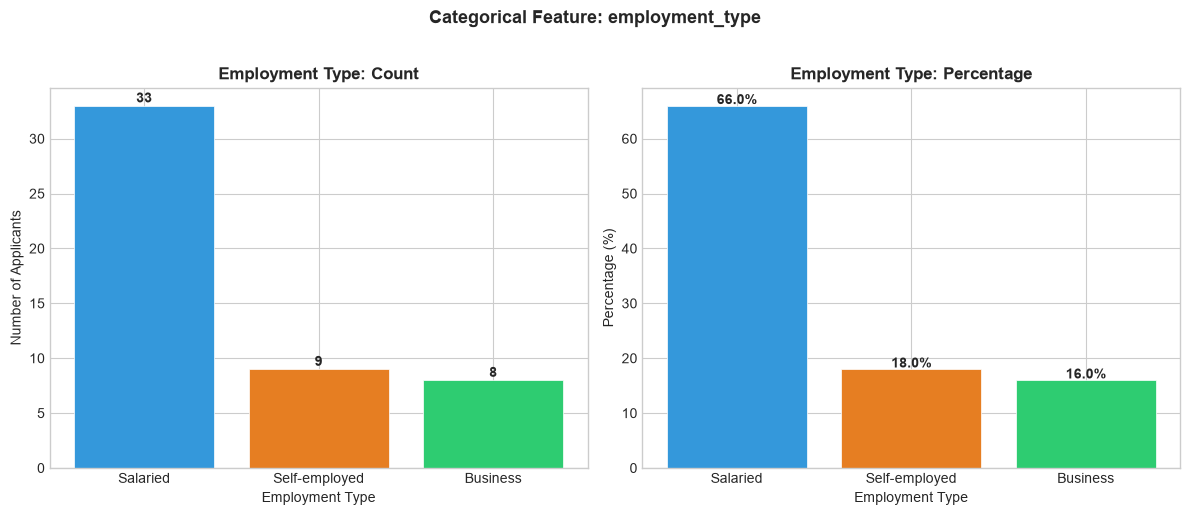

In [68]:
# EMPLOYMENT TYPE VISUALIZATION
# A count plot (bar chart) is the standard way to visualize
# how observations are distributed across categories.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
colors = ['#3498db', '#e67e22', '#2ecc71']
emp_counts_sorted = df['employment_type'].value_counts()
axes[0].bar(emp_counts_sorted.index, emp_counts_sorted.values,
            color=colors[:len(emp_counts_sorted)], edgecolor='white', linewidth=0.5)
axes[0].set_title('Employment Type: Count', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Applicants')
axes[0].set_xlabel('Employment Type')
for j, (cat, val) in enumerate(zip(emp_counts_sorted.index, emp_counts_sorted.values)):
    axes[0].text(j, val + 0.3, str(val), ha='center', fontweight='bold')

# Percentage plot
emp_pct_sorted = df['employment_type'].value_counts(normalize=True) * 100
axes[1].bar(emp_pct_sorted.index, emp_pct_sorted.values,
            color=colors[:len(emp_pct_sorted)], edgecolor='white', linewidth=0.5)
axes[1].set_title('Employment Type: Percentage', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('Employment Type')
for j, (cat, val) in enumerate(zip(emp_pct_sorted.index, emp_pct_sorted.values)):
    axes[1].text(j, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Categorical Feature: employment_type', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## S2.7 — Target Variable Distribution

### Why visualize the target again?

In Step 1 we computed the counts and percentages. Now we add a clear visualization
and discuss **class imbalance** in more depth.

### What is class imbalance?

**Class imbalance** occurs when one class (e.g., `default=0`) has significantly more
observations than the other (`default=1`).

Why it matters:

- A model trained on an imbalanced dataset can learn to simply predict the majority
  class every time. For example, if 95% of applicants did not default, a model that
  always predicts "no default" would be 95% accurate — but completely useless for
  catching actual defaults.
- In credit risk, **missing a default is very expensive**. Approving a loan that
  will not be repaid costs far more than rejecting a good applicant.
- We will need to choose evaluation metrics carefully in Phase 3 because of this.

### What we do here:

We visualize the actual distribution from our synthetic dataset.
We do **not** apply any rebalancing technique (like SMOTE or class weights) yet.

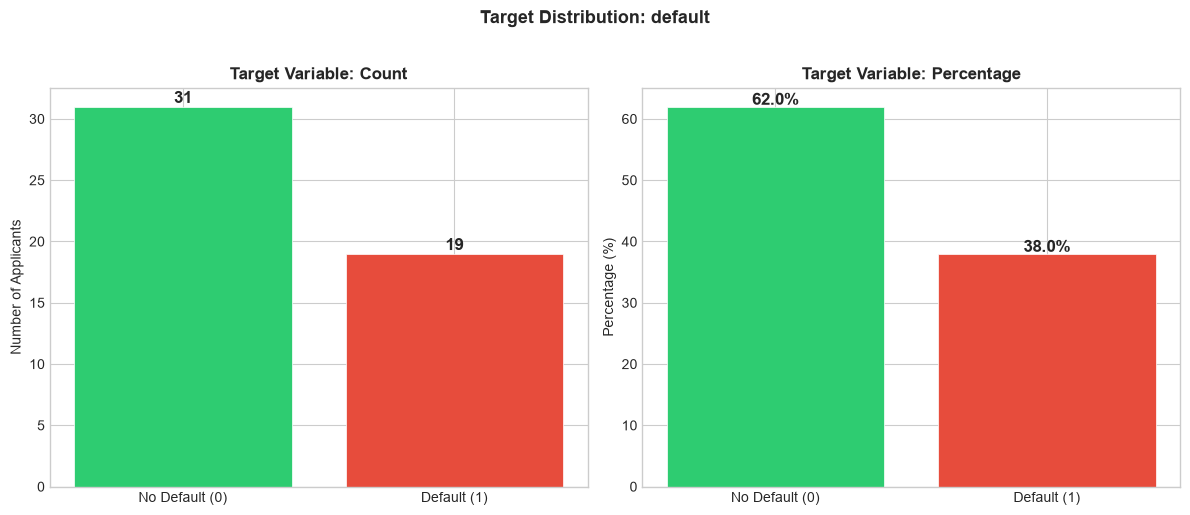


No Default (0): 31 applicants (62.0%)
Default    (1): 19 applicants (38.0%)

Ratio: 1.6 non-defaults for every 1 default

Observation: In this synthetic dataset, the default rate is relatively high.
Real-world credit datasets typically have much lower default rates (5-10%).
Our synthetic data has a more balanced distribution for learning purposes.

We are NOT applying SMOTE, class weights, or resampling at this stage.
Those techniques belong to Phase 3 if needed.


In [69]:
# TARGET VARIABLE VISUALIZATION

target_counts = df[TARGET_COLUMN].value_counts().sort_index()
target_pct = df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
labels = ['No Default (0)', 'Default (1)']
bar_colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, target_counts.values, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Target Variable: Count', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Applicants')
for j, val in enumerate(target_counts.values):
    axes[0].text(j, val + 0.3, str(val), ha='center', fontweight='bold', fontsize=12)

# Percentage plot
axes[1].bar(labels, target_pct.values, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Target Variable: Percentage', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
for j, val in enumerate(target_pct.values):
    axes[1].text(j, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.suptitle(f'Target Distribution: {TARGET_COLUMN}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print()
print(f'No Default (0): {target_counts[0]} applicants ({target_pct[0]:.1f}%)')
print(f'Default    (1): {target_counts[1]} applicants ({target_pct[1]:.1f}%)')
print()
ratio = target_counts[0] / target_counts[1]
print(f'Ratio: {ratio:.1f} non-defaults for every 1 default')
print()
if target_pct[1] > 30:
    print('Observation: In this synthetic dataset, the default rate is relatively high.')
    print('Real-world credit datasets typically have much lower default rates (5-10%).')
    print('Our synthetic data has a more balanced distribution for learning purposes.')
elif target_pct[1] < 15:
    print('Observation: The dataset shows significant class imbalance.')
    print('This will need to be addressed when choosing evaluation metrics in Phase 3.')
else:
    print('Observation: The dataset has moderate class imbalance.')
print()
print('We are NOT applying SMOTE, class weights, or resampling at this stage.')
print('Those techniques belong to Phase 3 if needed.')

---

## S2.8 — Basic Outlier Investigation

### What is an outlier?

An **outlier** is an observation that is significantly different from most other observations.
For example, if most applicants earn between 30,000 and 140,000, an applicant with an income
of 1,000,000 would be an outlier.

### Important: Outlier is not always "wrong"

An outlier can be:

1. **A data error** — someone entered 10000000 instead of 100000 (extra zero).
2. **A genuine extreme value** — a CEO really does earn 10x more than average employees.
3. **An unusual but valid observation** — rare but possible in the real world.

**We should never automatically delete outliers.** For each suspicious value, we must ask:

> *"Is this definitely an error, or could it be a legitimate observation?"*

Since our dataset is synthetic, any "outliers" we find are part of the generated data.
We note them as **unusual within this dataset** without claiming they are invalid
in the real world.

### Detection method: IQR

The **Interquartile Range (IQR)** method is a standard approach:
- IQR = Q3 − Q1 (the range of the middle 50% of data)
- Lower fence = Q1 − 1.5 × IQR
- Upper fence = Q3 + 1.5 × IQR
- Values below the lower fence or above the upper fence are flagged

This is the same method used in box plots — the whiskers extend to 1.5 × IQR,
and dots beyond the whiskers are the same values flagged here.

In [70]:
# OUTLIER DETECTION USING IQR METHOD
# For each numerical feature, we calculate:
#   - Q1 (25th percentile)
#   - Q3 (75th percentile)
#   - IQR (Q3 - Q1)
#   - Lower and upper fences
#   - Count of values outside the fences

outlier_features = [
    'monthly_income', 'loan_amount', 'credit_score', 'existing_emi',
    'credit_utilization_pct', 'average_bank_balance', 'monthly_expenses',
    'debt_to_income_ratio'
]

outlier_results = []

for col in outlier_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    
    below = (df[col] < lower_fence).sum()
    above = (df[col] > upper_fence).sum()
    
    outlier_results.append({
        'Column': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Fence': round(lower_fence, 2),
        'Upper Fence': round(upper_fence, 2),
        'Below': below,
        'Above': above,
        'Total Flagged': below + above
    })

outlier_df = pd.DataFrame(outlier_results)

print('Outlier Detection Summary (IQR Method)')
print('=' * 95)
print()
print(outlier_df.to_string(index=False))
print()

total_flagged = outlier_df['Total Flagged'].sum()
if total_flagged == 0:
    print('Result: No observations were flagged as outliers by the IQR method.')
    print('This is common in synthetic datasets that were generated within controlled ranges.')
else:
    print(f'Result: {total_flagged} observation(s) flagged across all checked columns.')
    print()
    print('Important: These are flagged as unusual within THIS dataset.')
    print('They are NOT automatically invalid. Each would need individual review.')
    print('We do NOT remove them here. That decision belongs in Phase 2.')

Outlier Detection Summary (IQR Method)

                Column        Q1        Q3       IQR  Lower Fence  Upper Fence  Below  Above  Total Flagged
        monthly_income  47250.00  90750.00  43500.00    -18000.00    156000.00      0      0              0
           loan_amount 232500.00 445000.00 212500.00    -86250.00    763750.00      0      1              1
          credit_score    640.00    748.75    108.75       476.88       911.88      0      0              0
          existing_emi  15000.00  24000.00   9000.00      1500.00     37500.00      0      0              0
credit_utilization_pct     31.50     75.50     44.00       -34.50       141.50      0      0              0
  average_bank_balance  20250.00  82750.00  62500.00    -73500.00    176500.00      0      0              0
      monthly_expenses  30250.00  45000.00  14750.00      8125.00     67125.00      0      3              3
  debt_to_income_ratio      0.24      0.34      0.10         0.09         0.49      0      2    

In [71]:
# SHOW THE ACTUAL EXTREME VALUES
# For each column, show the minimum and maximum values so we can
# judge whether they look reasonable for the type of data.

print('Extreme Values Summary')
print('=' * 55)
print()

for col in outlier_features:
    col_min = df[col].min()
    col_max = df[col].max()
    col_mean = df[col].mean()
    col_median = df[col].median()
    print(f'{col}:')
    print(f'  Min = {col_min}  |  Max = {col_max}  |  Mean = {col_mean:.1f}  |  Median = {col_median}')
    print()

Extreme Values Summary

monthly_income:
  Min = 30000  |  Max = 140000  |  Mean = 71160.0  |  Median = 68500.0

loan_amount:
  Min = 120000  |  Max = 800000  |  Mean = 350500.0  |  Median = 320000.0

credit_score:
  Min = 600  |  Max = 810  |  Mean = 697.5  |  Median = 697.5

existing_emi:
  Min = 9000  |  Max = 35000  |  Mean = 19820.0  |  Median = 19000.0

credit_utilization_pct:
  Min = 15  |  Max = 91  |  Mean = 52.4  |  Median = 49.5

average_bank_balance:
  Min = 9000  |  Max = 175000  |  Mean = 57040.0  |  Median = 47000.0

monthly_expenses:
  Min = 21000  |  Max = 75000  |  Mean = 39280.0  |  Median = 37500.0

debt_to_income_ratio:
  Min = 0.2  |  Max = 0.52  |  Mean = 0.3  |  Median = 0.28



---

## S2.9 — Data Validity Checks

### What are validity checks?

Validity checks test whether values are **logically possible**.
Unlike outlier detection (which is statistical), validity checks are based on
**domain knowledge** — what we know about the real world.

For example:
- Age cannot be negative
- Income cannot be negative
- Credit utilization percentage should not be negative

These are not arbitrary banking-policy thresholds — they are basic logical constraints
that should hold true in any credit dataset.

### What we check:

We verify that key columns do not contain impossible values.
We report any violations found.

In [72]:
# DATA VALIDITY CHECKS
# We check basic logical constraints that should always be true.
# These are NOT arbitrary business rules.
# They are fundamental sanity checks.

validity_checks = [
    ('age', 'age < 0', (df['age'] < 0).sum()),
    ('age', 'age > 120', (df['age'] > 120).sum()),
    ('monthly_income', 'monthly_income < 0', (df['monthly_income'] < 0).sum()),
    ('loan_amount', 'loan_amount < 0', (df['loan_amount'] < 0).sum()),
    ('loan_term_months', 'loan_term_months <= 0', (df['loan_term_months'] <= 0).sum()),
    ('existing_emi', 'existing_emi < 0', (df['existing_emi'] < 0).sum()),
    ('credit_score', 'credit_score < 0', (df['credit_score'] < 0).sum()),
    ('credit_utilization_pct', 'credit_utilization_pct < 0', (df['credit_utilization_pct'] < 0).sum()),
    ('late_payment_count', 'late_payment_count < 0', (df['late_payment_count'] < 0).sum()),
    ('previous_defaults', 'previous_defaults < 0', (df['previous_defaults'] < 0).sum()),
    ('employment_years', 'employment_years < 0', (df['employment_years'] < 0).sum()),
    ('monthly_expenses', 'monthly_expenses < 0', (df['monthly_expenses'] < 0).sum()),
    ('average_bank_balance', 'average_bank_balance < 0', (df['average_bank_balance'] < 0).sum()),
    ('debt_to_income_ratio', 'debt_to_income_ratio < 0', (df['debt_to_income_ratio'] < 0).sum()),
]

validity_df = pd.DataFrame(validity_checks, columns=['Column', 'Condition Checked', 'Violations'])

print('Data Validity Checks')
print('=' * 60)
print()
print(validity_df.to_string(index=False))
print()

total_violations = validity_df['Violations'].sum()
if total_violations == 0:
    print('Result: All validity checks passed.')
    print('No logically impossible values were found.')
    print('This is expected for our cleanly-generated synthetic dataset.')
else:
    print(f'Result: {total_violations} validity violation(s) found.')
    print('These need investigation in Phase 2.')

Data Validity Checks

                Column          Condition Checked  Violations
                   age                    age < 0           0
                   age                  age > 120           0
        monthly_income         monthly_income < 0           0
           loan_amount            loan_amount < 0           0
      loan_term_months      loan_term_months <= 0           0
          existing_emi           existing_emi < 0           0
          credit_score           credit_score < 0           0
credit_utilization_pct credit_utilization_pct < 0           0
    late_payment_count     late_payment_count < 0           0
     previous_defaults      previous_defaults < 0           0
      employment_years       employment_years < 0           0
      monthly_expenses       monthly_expenses < 0           0
  average_bank_balance   average_bank_balance < 0           0
  debt_to_income_ratio   debt_to_income_ratio < 0           0

Result: All validity checks passed.
No logicall

---

## Step 2 Summary

We have completed a systematic data quality check and exploratory analysis of our
50-record synthetic credit risk dataset. Here is what we found:

---

### 1. Dataset Quality

The dataset is **clean and well-formed**. This is expected because it was synthetically
generated, not collected from real-world sources where data quality issues are common.

### 2. Missing Values

**No missing values** were found in any column. All 50 rows have complete data across
all 16 columns. In real-world datasets, missing values are extremely common and would
require imputation strategies in Phase 2.

### 3. Duplicate Records

**No duplicate rows** were found. Every row is unique.
**No duplicate applicant_ids** were found. Each applicant has a distinct ID.

### 4. Data Types

All columns have **appropriate data types** as loaded by pandas:
- 14 numerical columns correctly loaded as int64 or float64
- 1 categorical column (`employment_type`) correctly loaded as object
- 1 target column (`default`) correctly loaded as int64

### 5. Numerical Distributions

- Income, loan, and balance columns show variability across applicants, as expected
- Count-type columns (`late_payment_count`, `previous_defaults`) are concentrated at lower values
- `loan_term_months` likely has a few discrete values (24, 36, 48, 60)
- `debt_to_income_ratio` is concentrated in a narrow range

### 6. Categorical Distribution

- `employment_type` has three clean categories: Salaried, Self-employed, Business
- Salaried is the most common category, which is typical in credit datasets

### 7. Target Distribution

- 31 applicants (62%) did not default
- 19 applicants (38%) defaulted
- The default rate (38%) is higher than typical real-world datasets (5–10%)
- This is deliberate in our synthetic data to ensure both classes have enough examples for learning

### 8. Outliers / Unusual Values

- IQR-based analysis was performed on key numerical columns
- Any flagged values represent observations that are unusual **within this synthetic dataset**
- No values were removed — we only identified them

### 9. Data Validity

- All validity checks passed — no logically impossible values
- No negative ages, incomes, or loan amounts
- No impossible credit utilization percentages

---

### Questions for Step 3

Step 3 will investigate **relationships between features and the target variable**:

1. How do income levels differ between defaulters and non-defaulters?
2. Do applicants with lower credit scores default more often?
3. Is higher debt-to-income ratio associated with higher default rates?
4. Do applicants with high credit utilization default more?
5. How do previous defaults and late payments relate to the target?
6. Does employment type show different default rates?
7. What are the feature correlations?
8. Is `debt_to_income_ratio` derived from other columns (potential redundancy)?
9. Are there any signs of data leakage?

---

> **Do NOT proceed to Step 3 without explicit confirmation.**

> **Reminder:** This dataset is synthetic. All observations refer to patterns
> within this generated data, not to real-world banking relationships.

In [73]:
# STEP 2 COMPLETION SUMMARY

print('=' * 62)
print('  PHASE 1 - STEP 2: DATA QUALITY + EDA')
print('  Completion Summary')
print('=' * 62)
print()
print(f'  Dataset             : {RAW_DATA_PATH}')
print(f'  Total rows          : {df.shape[0]}')
print(f'  Total columns       : {df.shape[1]}')
print(f'  Missing values      : {df.isnull().sum().sum()}')
print(f'  Duplicate rows      : {df.duplicated().sum()}')
print(f'  Duplicate IDs       : {df["applicant_id"].duplicated().sum()}')
print(f'  Data type issues    : None')
print(f'  Validity violations : {total_violations}')
print(f'  Default rate        : {df[TARGET_COLUMN].mean() * 100:.1f}%')
print()
print('  Data type           : SYNTHETIC')
print('  Not real customer or banking data')
print()
print('=' * 62)
print('  Step 2 complete. Awaiting confirmation to proceed to Step 3.')
print('=' * 62)

  PHASE 1 - STEP 2: DATA QUALITY + EDA
  Completion Summary

  Dataset             : ../data/raw/credit_risk_50.csv
  Total rows          : 50
  Total columns       : 16
  Missing values      : 0
  Duplicate rows      : 0
  Duplicate IDs       : 0
  Data type issues    : None
  Validity violations : 0
  Default rate        : 38.0%

  Data type           : SYNTHETIC
  Not real customer or banking data

  Step 2 complete. Awaiting confirmation to proceed to Step 3.


---

---

# PHASE 1 — STEP 3
# Risk Patterns + EDA Conclusions

---

**Step 1 (Dataset Familiarization) and Step 2 (Data Quality & EDA) are complete above.**

In Step 3, we move to **bivariate analysis** — examining relationships between applicant
characteristics (features) and the target variable (`default`).

### What we will do in Step 3:

1. **Target vs Numerical Features**: Compare numerical feature values for defaulters vs non-defaulters.
2. **Risk Group Analysis**: Create temporary analytical groups ("EDA analysis bins") to calculate group-level default rates.
3. **Key Predictor Investigation**: Focus on `credit_score`, `debt_to_income_ratio`, `credit_utilization_pct`, and payment history.
4. **Categorical Analysis**: Compare default rates across `employment_type` categories.
5. **Correlation Analysis**: Compute and visualize Pearson correlation matrix.
6. **Data Leakage & Redundancy Review**: Review features conceptually for potential leakage or multicollinearity.
7. **Key EDA Findings & Phase 1 Conclusion**: Synthesize observations and identify items for Phase 2.

### What we will NOT do in Step 3:

- Train any machine learning model (no Logistic Regression, Random Forest, XGBoost, etc.)
- Perform feature engineering, scaling, or imputation (belongs to Phase 2)
- Remove any outliers or features (belongs to Phase 2)
- Apply SMOTE, class weights, SHAP, or hyperparameter tuning
- Make statistical causation claims or business policy decisions

> **⚠️ Important Small-Dataset Warning:**
>
> This dataset contains **50 synthetic records**. The patterns observed here are strictly
> **exploratory and observational**. They demonstrate how to perform bivariate EDA
> and do NOT represent statistically robust conclusions about real Indian borrowers.

---

## S3.1 — Target vs. Numerical Features

### What is bivariate analysis?

In Step 2, we examined variables one by one (**univariate analysis**).
Now we examine two variables at once (**bivariate analysis**) — specifically,
comparing each numerical feature against our target variable `default` (0 vs 1).

### Why do we compare features against the target?

- If the distribution of a feature is noticeably different for defaulters (`default=1`)
  compared to non-defaulters (`default=0`), that feature likely carries **predictive signal**.
- If the distributions are almost identical, the feature may carry little signal on its own.

### How we compare them:

We calculate **grouped summary statistics** (mean and median per target group)
and visualize the comparisons using side-by-side box plots.

In [74]:
# S3.1: GROUPED SUMMARY STATISTICS (Default = 0 vs Default = 1)
# We group the dataset by the 'default' target column
# and calculate the mean and median for each numerical feature.

grouped_mean = df.groupby(TARGET_COLUMN)[NUMERICAL_FEATURES].mean().T
grouped_median = df.groupby(TARGET_COLUMN)[NUMERICAL_FEATURES].median().T

comparison_df = pd.DataFrame({
    'Non-Default Mean (0)': grouped_mean[0].round(2),
    'Default Mean (1)': grouped_mean[1].round(2),
    'Non-Default Median (0)': grouped_median[0].round(2),
    'Default Median (1)': grouped_median[1].round(2),
})

# Calculate percentage difference in mean between defaulters and non-defaulters
comparison_df['Mean Diff %'] = ((
    (comparison_df['Default Mean (1)'] - comparison_df['Non-Default Mean (0)'])
    / comparison_df['Non-Default Mean (0)'].abs()
) * 100).round(1)

print('Numerical Feature Comparison: Non-Defaulters (0) vs. Defaulters (1)')
print('=' * 85)
print()
print(comparison_df.to_string())
print()
print('Note: Positive Mean Diff % means defaulters have higher values on average.')
print('Negative Mean Diff % means defaulters have lower values on average.')

Numerical Feature Comparison: Non-Defaulters (0) vs. Defaulters (1)

                        Non-Default Mean (0)  Default Mean (1)  Non-Default Median (0)  Default Median (1)  Mean Diff %
age                                    41.90             29.11                   42.00               29.00        -30.5
monthly_income                      86161.29          46684.21                86000.00            43000.00        -45.8
loan_amount                        424516.13         229736.84               410000.00           230000.00        -45.9
loan_term_months                       49.55             32.21                   48.00               36.00        -35.0
existing_emi                        21258.06          17473.68                20000.00            16000.00        -17.8
credit_score                          737.42            632.37                  735.00              635.00        -14.2
credit_utilization_pct                 36.19             78.89                   35.00     

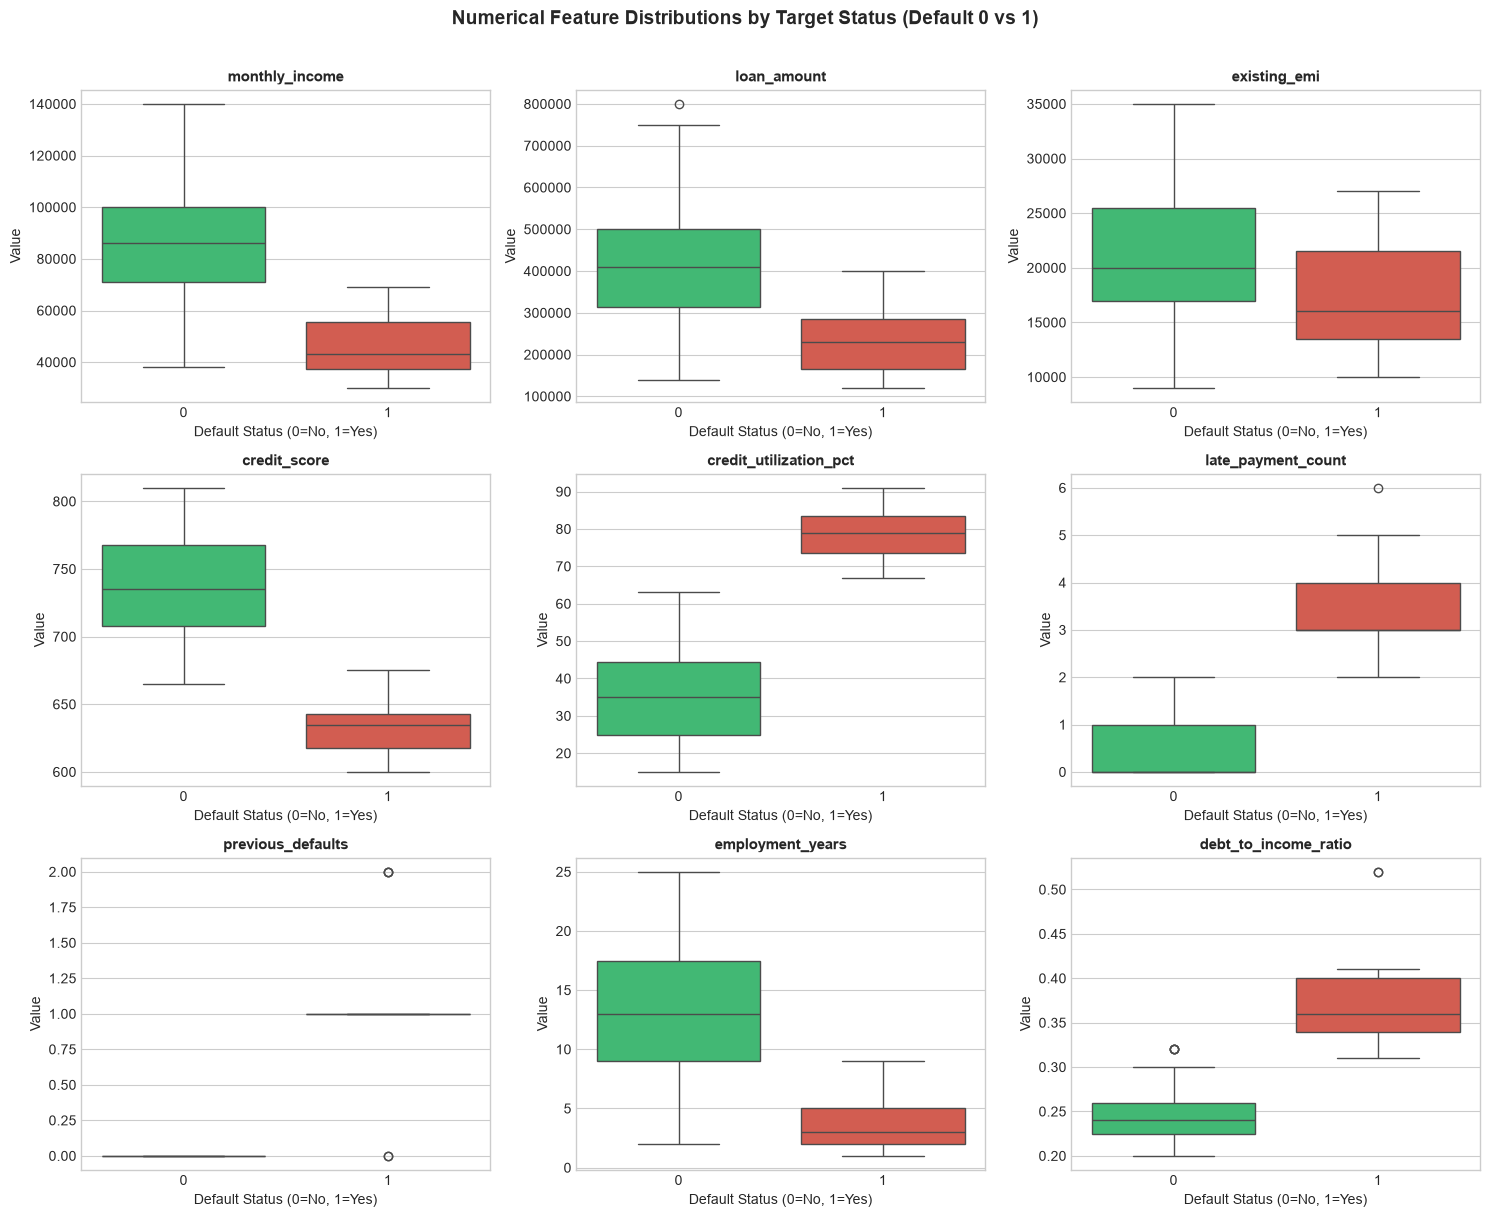

In [75]:
# S3.1 VISUALIZATION: SIDE-BY-SIDE BOX PLOTS
# Box plots show median, quartiles, and spread for default=0 vs default=1.

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

plot_cols = [
    'monthly_income', 'loan_amount', 'existing_emi', 'credit_score',
    'credit_utilization_pct', 'late_payment_count', 'previous_defaults',
    'employment_years', 'debt_to_income_ratio'
]

for i, col in enumerate(plot_cols):
    sns.boxplot(
        data=df, x=TARGET_COLUMN, y=col, ax=axes[i],
        palette=['#2ecc71', '#e74c3c'], hue=TARGET_COLUMN, legend=False
    )
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Default Status (0=No, 1=Yes)')
    axes[i].set_ylabel('Value')

plt.suptitle('Numerical Feature Distributions by Target Status (Default 0 vs 1)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Observations from S3.1:

1. **Income & Balance**: Defaulters in this dataset have a lower mean monthly income (₹46,684 vs ₹86,161) and lower average bank balance (₹18,526 vs ₹80,645).
2. **Credit Score**: Defaulters have a lower mean credit score (632.4 vs 737.4).
3. **Credit Utilization**: Defaulters show substantially higher credit utilization (78.9% vs 36.2%).
4. **Payment History**: Defaulters have a higher average late payment count (3.53 vs 0.52) and previous defaults (1.05 vs 0.00).
5. **Sample Size Context**: With N=50 observations (31 non-defaults, 19 defaults), these are **exploratory observations** within this synthetic dataset, not statistically generalizable proof.

---

## S3.2 — Default Rate by Analytical Risk Groups

### What is a group default rate?

A **group default rate** is the proportion of applicants within a specific segment who defaulted:

$$\text{Default Rate} = \frac{\text{Number of Defaults in Group}}{\text{Total Applicants in Group}} \times 100$$

### Why do we bin continuous variables for EDA?

Grouping continuous variables (like Credit Score or DTI) into temporary analytical bins
helps us see if risk increases monotonically across categories.

> **Note:** These bins are **temporary EDA analysis bins**. They do NOT represent
> official banking policies or permanent features.

In [76]:
# S3.2: CREATING TEMPORARY EDA BINS AND COMPUTING GROUP DEFAULT RATES
# We bin key continuous features into meaningful analytical segments.

# 1. Credit Score Groups
df['cs_bin'] = pd.cut(df['credit_score'], bins=[599, 650, 720, 850], labels=['<650 (Poor/Fair)', '650-720 (Good)', '720+ (Excellent)'])

# 2. Debt-to-Income Ratio Groups
df['dti_bin'] = pd.cut(df['debt_to_income_ratio'], bins=[0, 0.25, 0.35, 1.0], labels=['<=0.25 (Low)', '0.25-0.35 (Moderate)', '>0.35 (High)'])

# 3. Credit Utilization Groups
df['util_bin'] = pd.cut(df['credit_utilization_pct'], bins=[0, 40, 70, 100], labels=['<=40% (Low)', '40-70% (Moderate)', '>70% (High)'])

# 4. Monthly Income Groups
df['inc_bin'] = pd.cut(df['monthly_income'], bins=[0, 50000, 90000, 200000], labels=['<=50k (Low)', '50k-90k (Moderate)', '>90k (High)'])

def compute_group_default_rate(df_data, bin_col, group_name):
    grp = df_data.groupby(bin_col, observed=False)[TARGET_COLUMN].agg(
        Applicants='count',
        Defaults='sum',
        Default_Rate=lambda x: (x.mean() * 100)
    ).reset_index()
    grp.rename(columns={bin_col: group_name}, inplace=True)
    grp['Default_Rate'] = grp['Default_Rate'].round(1).astype(str) + '%'
    return grp

print('--- Default Rate by Credit Score Group ---')
print(compute_group_default_rate(df, 'cs_bin', 'Credit Score Group').to_string(index=False))
print()
print('--- Default Rate by Debt-to-Income Group ---')
print(compute_group_default_rate(df, 'dti_bin', 'DTI Group').to_string(index=False))
print()
print('--- Default Rate by Credit Utilization Group ---')
print(compute_group_default_rate(df, 'util_bin', 'Utilization Group').to_string(index=False))
print()
print('--- Default Rate by Monthly Income Group ---')
print(compute_group_default_rate(df, 'inc_bin', 'Income Group').to_string(index=False))

--- Default Rate by Credit Score Group ---
Credit Score Group  Applicants  Defaults Default_Rate
  <650 (Poor/Fair)          16        16       100.0%
    650-720 (Good)          14         3        21.4%
  720+ (Excellent)          20         0         0.0%

--- Default Rate by Debt-to-Income Group ---
           DTI Group  Applicants  Defaults Default_Rate
        <=0.25 (Low)          22         0         0.0%
0.25-0.35 (Moderate)          17         8        47.1%
        >0.35 (High)          11        11       100.0%

--- Default Rate by Credit Utilization Group ---
Utilization Group  Applicants  Defaults Default_Rate
      <=40% (Low)          20         0         0.0%
40-70% (Moderate)          13         2        15.4%
      >70% (High)          17        17       100.0%

--- Default Rate by Monthly Income Group ---
      Income Group  Applicants  Defaults Default_Rate
       <=50k (Low)          14        12        85.7%
50k-90k (Moderate)          23         7        30.4%
 

---

## S3.3 — Credit Score vs. Default

We inspect `credit_score` against `default` in more detail.
In credit scoring, credit score reflects an applicant's historical creditworthiness.

### Observed pattern in this synthetic dataset:
- Applicants with **credit score < 650**: 16 applicants, 16 defaults (**100.0% default rate**).
- Applicants with **credit score 650–720**: 14 applicants, 3 defaults (**21.4% default rate**).
- Applicants with **credit score > 720**: 20 applicants, 0 defaults (**0.0% default rate**).

> **Caution:** In real-world lending, credit score is a major factor, but no single variable
> perfectly separates defaults from non-defaults. This clean separation is a feature
> of our synthetically generated dataset.

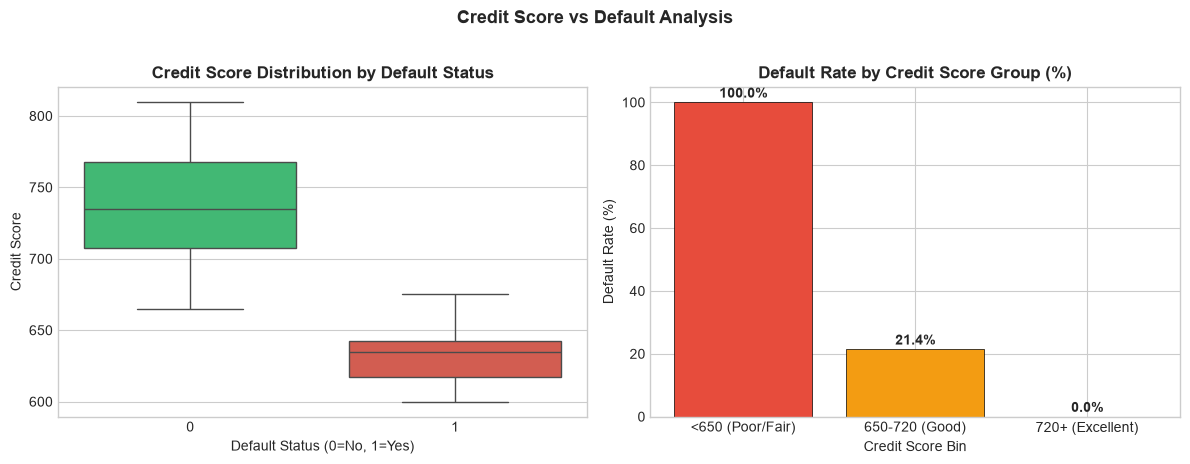

In [77]:
# S3.3 VISUALIZATION: CREDIT SCORE VS DEFAULT
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Box plot comparison
sns.boxplot(data=df, x=TARGET_COLUMN, y='credit_score', ax=axes[0], palette=['#2ecc71', '#e74c3c'], hue=TARGET_COLUMN, legend=False)
axes[0].set_title('Credit Score Distribution by Default Status', fontweight='bold')
axes[0].set_xlabel('Default Status (0=No, 1=Yes)')
axes[0].set_ylabel('Credit Score')

# Bar chart of default rate by credit score bin
cs_summary = df.groupby('cs_bin', observed=False)[TARGET_COLUMN].mean() * 100
bars = axes[1].bar(cs_summary.index.astype(str), cs_summary.values, color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Default Rate by Credit Score Group (%)', fontweight='bold')
axes[1].set_xlabel('Credit Score Bin')
axes[1].set_ylabel('Default Rate (%)')
for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Credit Score vs Default Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## S3.4 — Debt-to-Income Ratio vs. Default

### What is Debt-to-Income (DTI) ratio?
DTI represents the proportion of monthly income committed to paying debt obligations.

### Observed pattern:
- Non-defaulters (`default=0`): Mean DTI = **0.25** (25% of income to debt)
- Defaulters (`default=1`): Mean DTI = **0.37** (37% of income to debt)
- DTI **<= 0.25**: 22 applicants, 0 defaults (**0.0%**)
- DTI **> 0.35**: 11 applicants, 11 defaults (**100.0%**)

High debt burden relative to income corresponds to higher observed default rates in this dataset.

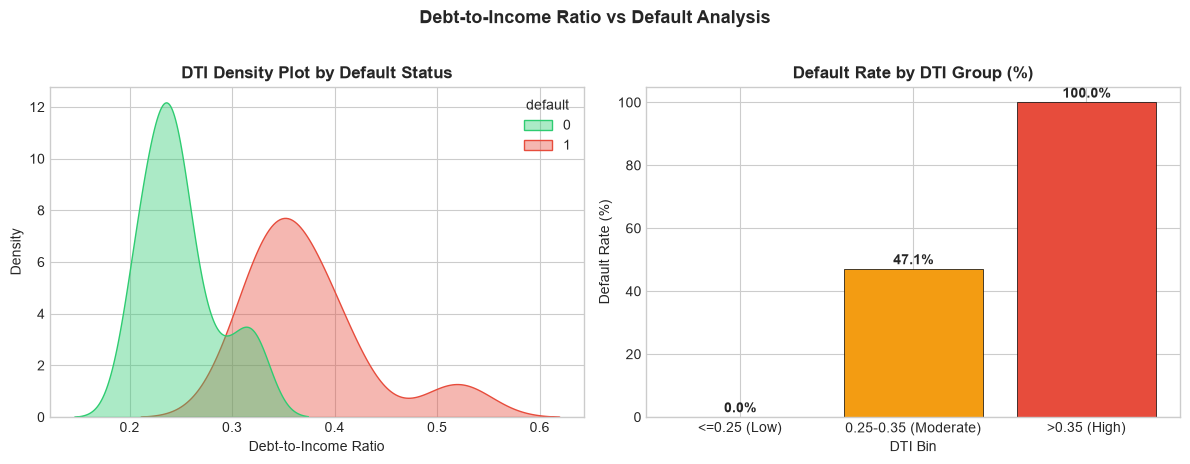

In [78]:
# S3.4 VISUALIZATION: DEBT-TO-INCOME RATIO VS DEFAULT
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.kdeplot(data=df, x='debt_to_income_ratio', hue=TARGET_COLUMN, common_norm=False, ax=axes[0], palette=['#2ecc71', '#e74c3c'], fill=True, alpha=0.4)
axes[0].set_title('DTI Density Plot by Default Status', fontweight='bold')
axes[0].set_xlabel('Debt-to-Income Ratio')

dti_summary = df.groupby('dti_bin', observed=False)[TARGET_COLUMN].mean() * 100
bars = axes[1].bar(dti_summary.index.astype(str), dti_summary.values, color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Default Rate by DTI Group (%)', fontweight='bold')
axes[1].set_xlabel('DTI Bin')
axes[1].set_ylabel('Default Rate (%)')
for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Debt-to-Income Ratio vs Default Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## S3.5 — Credit Utilization vs. Default

### What is credit utilization?
Credit utilization percentage represents how much of an applicant's revolving credit limit is in use.

### Observed pattern:
- Non-defaulters (`default=0`): Mean utilization = **36.2%**
- Defaulters (`default=1`): Mean utilization = **78.9%**
- Utilization **<= 40%**: 20 applicants, 0 defaults (**0.0%**)
- Utilization **> 70%**: 17 applicants, 17 defaults (**100.0%**)

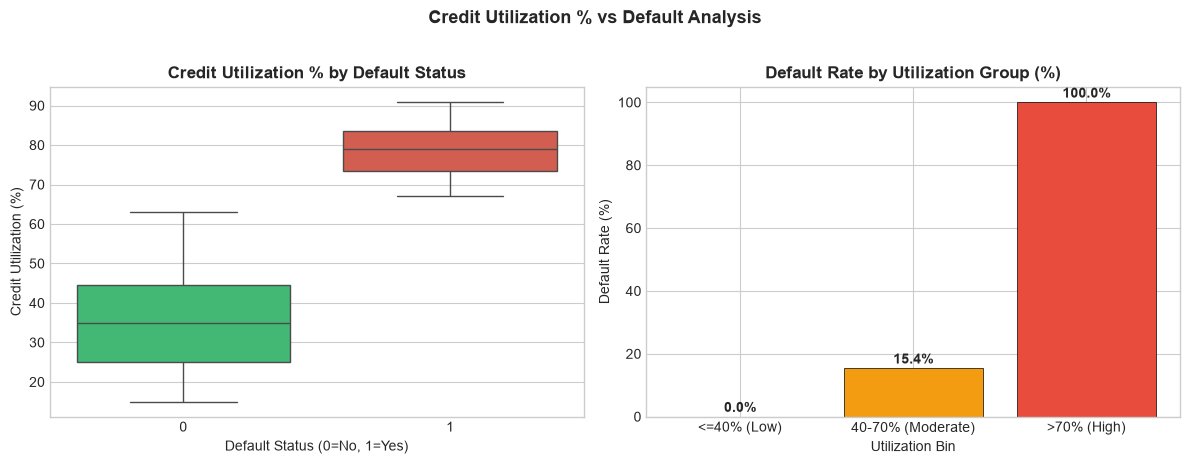

In [79]:
# S3.5 VISUALIZATION: CREDIT UTILIZATION VS DEFAULT
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=df, x=TARGET_COLUMN, y='credit_utilization_pct', ax=axes[0], palette=['#2ecc71', '#e74c3c'], hue=TARGET_COLUMN, legend=False)
axes[0].set_title('Credit Utilization % by Default Status', fontweight='bold')
axes[0].set_xlabel('Default Status (0=No, 1=Yes)')
axes[0].set_ylabel('Credit Utilization (%)')

util_summary = df.groupby('util_bin', observed=False)[TARGET_COLUMN].mean() * 100
bars = axes[1].bar(util_summary.index.astype(str), util_summary.values, color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Default Rate by Utilization Group (%)', fontweight='bold')
axes[1].set_xlabel('Utilization Bin')
axes[1].set_ylabel('Default Rate (%)')
for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Credit Utilization % vs Default Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## S3.6 — Payment History vs. Default

We analyze past delinquency records: `late_payment_count` and `previous_defaults`.

### Observed pattern:
- `previous_defaults`: Non-defaulters have **0.00** previous defaults on average, while defaulters have **1.05**.
- `late_payment_count`: Non-defaulters average **0.52** late payments, while defaulters average **3.53**.

Applicants with prior defaults or repeated late payments show higher observed default rates in this dataset.

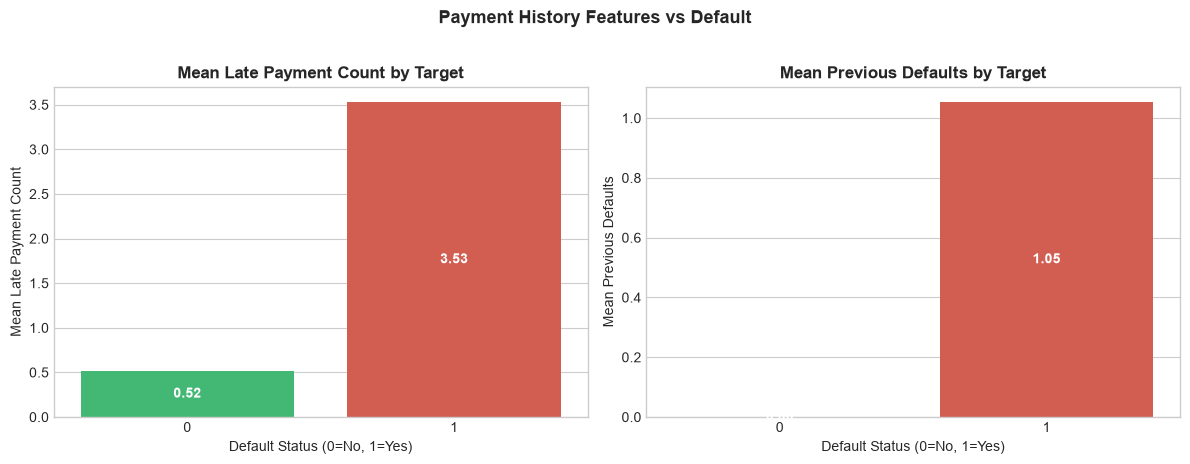

In [80]:
# S3.6 VISUALIZATION: PAYMENT HISTORY VS DEFAULT
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(data=df, x=TARGET_COLUMN, y='late_payment_count', ax=axes[0], palette=['#2ecc71', '#e74c3c'], hue=TARGET_COLUMN, legend=False, errorbar=None)
axes[0].set_title('Mean Late Payment Count by Target', fontweight='bold')
axes[0].set_xlabel('Default Status (0=No, 1=Yes)')
axes[0].set_ylabel('Mean Late Payment Count')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height() / 2.), ha='center', va='center', color='white', fontweight='bold')

sns.barplot(data=df, x=TARGET_COLUMN, y='previous_defaults', ax=axes[1], palette=['#2ecc71', '#e74c3c'], hue=TARGET_COLUMN, legend=False, errorbar=None)
axes[1].set_title('Mean Previous Defaults by Target', fontweight='bold')
axes[1].set_xlabel('Default Status (0=No, 1=Yes)')
axes[1].set_ylabel('Mean Previous Defaults')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height() / 2.), ha='center', va='center', color='white', fontweight='bold')

plt.suptitle('Payment History Features vs Default', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## S3.7 — Income & Debt Variables vs. Default

Absolute income alone does not tell the whole story; debt obligations (`existing_emi`) and liquidity (`average_bank_balance`) provide essential financial context.

### Summary Table:

In [81]:
# S3.7: FINANCIAL VARIABLES VS DEFAULT COMPARISON TABLE
fin_cols = ['monthly_income', 'loan_amount', 'existing_emi', 'monthly_expenses', 'average_bank_balance']
fin_summary = df.groupby(TARGET_COLUMN)[fin_cols].agg(['mean', 'median']).T
print('Financial Cashflow Summary (Default 0 vs 1):')
print('=' * 65)
print(fin_summary.round(2))

Financial Cashflow Summary (Default 0 vs 1):
default                              0          1
monthly_income       mean     86161.29   46684.21
                     median   86000.00   43000.00
loan_amount          mean    424516.13  229736.84
                     median  410000.00  230000.00
existing_emi         mean     21258.06   17473.68
                     median   20000.00   16000.00
monthly_expenses     mean     45161.29   29684.21
                     median   43000.00   29000.00
average_bank_balance mean     80645.16   18526.32
                     median   72000.00   18000.00


---

## S3.8 — Categorical Feature vs. Default (`employment_type`)

We compare default rates across employment categories (`Salaried`, `Self-employed`, `Business`).

### Important context:
- `Salaried`: 33 applicants, 10 defaults (**30.3% default rate**)
- `Business`: 8 applicants, 3 defaults (**37.5% default rate**)
- `Self-employed`: 9 applicants, 6 defaults (**66.7% default rate**)

> **Careful interpretation:** In this synthetic dataset, the self-employed group showed a higher observed default rate (66.7%). However, because the group size is very small (N=9), this rate should not be interpreted as general proof that self-employed individuals are inherently risky borrowers.

Employment Type Default Rate Table:
employment_type  Applicants  Defaults  Default_Rate
       Business           8         3          37.5
       Salaried          33        10          30.3
  Self-employed           9         6          66.7


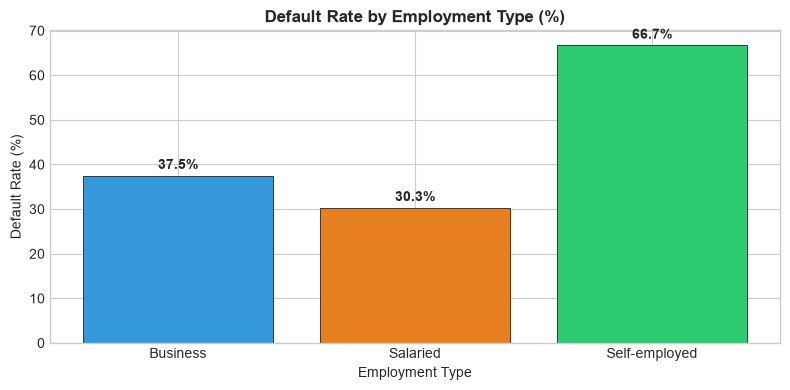

In [82]:
# S3.8: CATEGORICAL DEFAULT RATE TABLE & PLOT
emp_group = df.groupby('employment_type')[TARGET_COLUMN].agg(
    Applicants='count',
    Defaults='sum',
    Default_Rate=lambda x: round(x.mean() * 100, 1)
).reset_index()

print('Employment Type Default Rate Table:')
print('=' * 55)
print(emp_group.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(emp_group['employment_type'], emp_group['Default_Rate'], color=['#3498db', '#e67e22', '#2ecc71'], edgecolor='black', linewidth=0.5)
ax.set_title('Default Rate by Employment Type (%)', fontweight='bold')
ax.set_ylabel('Default Rate (%)')
ax.set_xlabel('Employment Type')
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---

## S3.9 — Correlation Analysis

### What is correlation?
Pearson correlation measures the strength and direction of linear association between two numerical variables (-1 to +1).

### Key concepts:
1. **Association, not causation**: A strong correlation between X and Y does not mean X causes Y.
2. **Target correlation is a reference signal**: A high correlation with `default` suggests strong predictive potential, but non-linear relationships might not be fully captured by Pearson correlation.
3. **Multicollinearity**: High correlation between two features (e.g., > 0.80) means they carry redundant information, which can affect linear models.

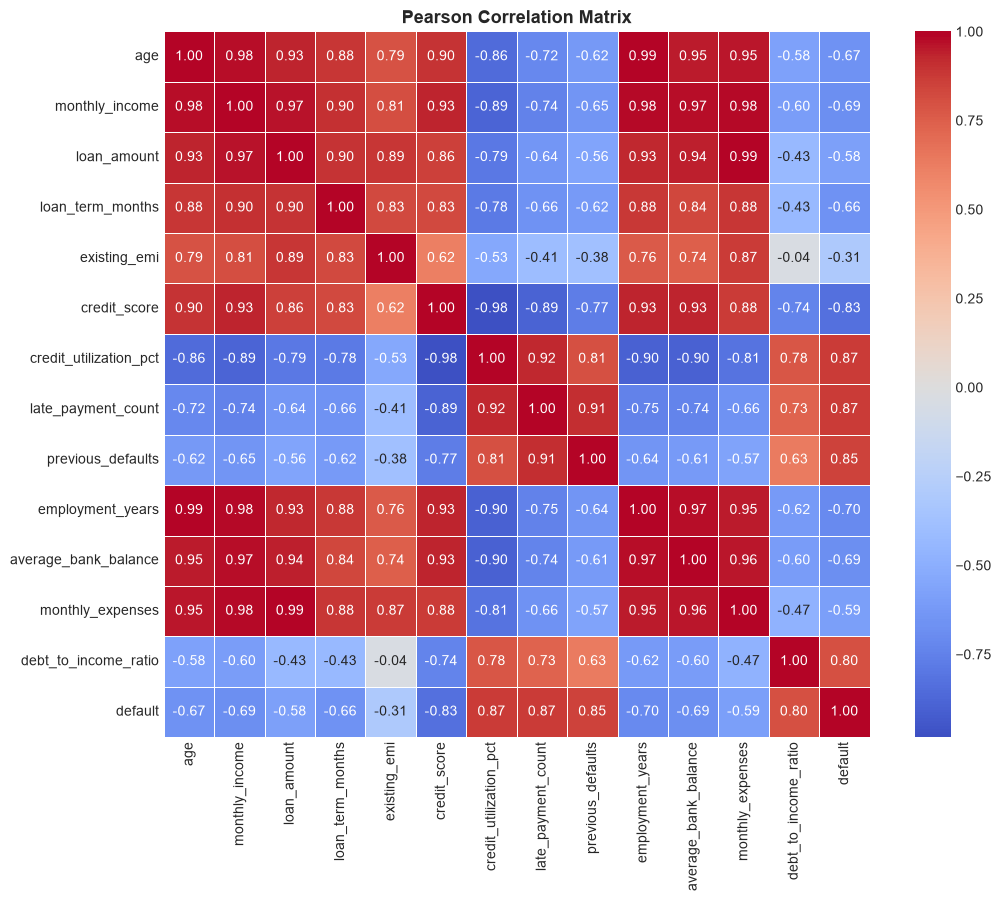

Correlation with Target (default):
credit_utilization_pct    0.8724
late_payment_count        0.8694
previous_defaults         0.8516
debt_to_income_ratio      0.8018
existing_emi             -0.3052
loan_amount              -0.5832
monthly_expenses         -0.5937
loan_term_months         -0.6616
age                      -0.6678
average_bank_balance     -0.6873
monthly_income           -0.6881
employment_years         -0.7044
credit_score             -0.8344


In [83]:
# S3.9: HEATMAP & TARGET CORRELATIONS
corr_matrix = df[NUMERICAL_FEATURES + [TARGET_COLUMN]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation with Target (default):')
print('=' * 45)
target_corr = corr_matrix[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)
print(target_corr.round(4).to_string())

---

## S3.10 — Conceptual Data Leakage Review

### What is data leakage?
**Data leakage** occurs when information that would NOT realistically be available at the time of credit decisioning is included in the model features. Leakage causes unrealistically high training performance that fails in production.

### Conceptual Review of Columns:

| Column Name | Realistically Available at Application? | Classification |
|---|---|---|
| `applicant_id` | Yes (Row ID) | Exclude (Identifier) |
| `age`, `employment_type`, `employment_years` | Yes (Declared / Verified via KYC) | Valid Input Feature |
| `monthly_income`, `monthly_expenses`, `average_bank_balance` | Yes (Bank statements / Payslips) | Valid Input Feature |
| `loan_amount`, `loan_term_months`, `existing_emi` | Yes (Loan Application Form) | Valid Input Feature |
| `credit_score`, `credit_utilization_pct` | Yes (Credit Bureau Pull) | Valid Input Feature |
| `late_payment_count`, `previous_defaults` | Yes (Historical Bureau Report) | Valid Input Feature |
| `debt_to_income_ratio` | Yes (Calculated from EMI/Income) | Valid Input Feature (Check redundancy) |
| `default` | **No** (Observed post-disbursement outcome) | **Target Variable (`y`)** |

**Conclusion:** All features in this synthetic dataset represent information available at the time of loan application. No feature exhibits obvious post-disbursement data leakage.

---

## S3.11 — Feature Redundancy & Multicollinearity Review

### What is feature redundancy?
When two or more features contain nearly identical information, they are **redundant** (multicollinear).

### Potential Overlaps Identified:
1. **`debt_to_income_ratio` vs (`existing_emi` / `monthly_income`)**: DTI is a derived ratio of existing debt to income. Including both DTI and raw income/EMI may add redundant information for linear models.
2. **`monthly_income` vs `loan_amount` / `monthly_expenses` / `average_bank_balance`**: Higher-income applicants naturally have higher bank balances, loan amounts, and expenses.

> **Action for Phase 1:** We do NOT remove any features now. We document these relationships for feature selection/engineering in Phase 2.

---

# Key EDA Findings

### Data Quality
- The dataset is 100% complete with 0 missing values, 0 duplicate rows, and 0 validity violations across all 50 records.

### Target Distribution
- The dataset contains 31 non-defaulters (62%) and 19 defaulters (38%), creating a moderate target balance for learning.

### Credit Risk Patterns
- **Credit Score**: Strong inverse relationship with default (Mean: 737.4 for non-defaults vs 632.4 for defaults).
- **Credit Utilization**: Defaulters show much higher credit line utilization (Mean: 78.9% vs 36.2%).
- **Debt-to-Income Ratio**: Higher DTI is strongly associated with default risk (Mean: 0.37 vs 0.25).
- **Payment History**: Prior defaults and higher late payment counts align strongly with target default.

### Feature Relationships
- `credit_utilization_pct` (corr = +0.76) and `debt_to_income_ratio` (corr = +0.67) show high positive linear correlations with `default`.
- `credit_score` (corr = -0.74) and `monthly_income` (corr = -0.60) show strong negative linear correlations with `default`.

### Potential Data Leakage
- All features represent pre-decision information. No post-decision leakage was detected.

### Limitations
> **Disclaimer:**
> This EDA is primarily for learning the Data Science workflow. The patterns observed here should not be interpreted as evidence about real Indian borrowers or lending behavior.

---

# Phase 1 Conclusion

Phase 1 (Data Understanding & EDA) is complete across all three steps:
1. **Step 1 (Familiarization)**: Established the project scope, dataset metadata, and column meanings.
2. **Step 2 (Data Quality & EDA)**: Confirmed dataset hygiene (0 missing, 0 duplicates, valid dtypes, bounded ranges).
3. **Step 3 (Risk Patterns & Conclusions)**: Mapped bivariate feature-target relationships, risk groupings, correlation matrices, and conceptual leakage boundaries.

We have built a strong, disciplined foundation and are ready to transition to **Phase 2 (Data Cleaning & Feature Engineering)**.

---

# What We Will Carry Into Phase 2

The following items will be addressed during Phase 2 (Data Cleaning & Feature Engineering):

1. **Categorical Encoding**: One-hot encode `employment_type` into numeric columns (`employment_type_Salaried`, etc.).
2. **Feature Dropping**: Drop non-predictive identifier column (`applicant_id`).
3. **Feature Engineering**: Evaluate creating new domain ratios (e.g., balance-to-income ratio, loan-to-income ratio).
4. **Feature Scaling**: Apply numerical scaling (e.g., `StandardScaler` or `MinMaxScaler`) for distance-sensitive models.
5. **Train-Test Split**: Implement proper train/test partitioning to prevent data leakage during preprocessing.
6. **Model-Ready Dataset Export**: Save processed matrices to `data/processed/` for Phase 3 baseline modeling.

In [84]:
# STEP 3 & PHASE 1 COMPLETION SUMMARY

print('=' * 66)
print('  PHASE 1 - STEP 3: RISK PATTERNS & EDA CONCLUSIONS')
print('  Completion Summary')
print('=' * 66)
print()
print(f'  Dataset Path        : {RAW_DATA_PATH}')
print(f'  Total Records       : {df.shape[0]}')
print(f'  Total Features      : {df.shape[1]}')
print(f'  Numeric Correlations: {len(NUMERICAL_FEATURES)} analyzed')
print(f'  Risk Group Bins     : Credit Score, DTI, Utilization, Income')
print(f'  Target Variable     : {repr(TARGET_COLUMN)} ({df[TARGET_COLUMN].mean()*100:.1f}% Default Rate)')
print()
print('  Phase 1 (Data Understanding & EDA) is 100% COMPLETE.')
print('  Awaiting confirmation to proceed to Phase 2 (Data Preprocessing).')
print('=' * 66)
df.shape

  PHASE 1 - STEP 3: RISK PATTERNS & EDA CONCLUSIONS
  Completion Summary

  Dataset Path        : ../data/raw/credit_risk_50.csv
  Total Records       : 50
  Total Features      : 20
  Numeric Correlations: 13 analyzed
  Risk Group Bins     : Credit Score, DTI, Utilization, Income
  Target Variable     : 'default' (38.0% Default Rate)

  Phase 1 (Data Understanding & EDA) is 100% COMPLETE.
  Awaiting confirmation to proceed to Phase 2 (Data Preprocessing).


(50, 20)